In [3]:
## 2026.02.11 using FineST env
## 2026.02.12 vilization cell type of each ROI

## Load anno data

In [1]:
path = '/home/lingyu/ssd2/Python/'
therapy_data = 'NCRT'
segment_data = 'NCRT_project - seg 1-14'
export_data = 'export'

In [2]:
import sys
import os
import pandas as pd
import importlib

# Add the code directory to Python path
code_dir = f'{path}Hist2Pheno/code/Hist2Pheno_pkg'
if code_dir not in sys.path:
    sys.path.insert(0, code_dir)

# Import (or reload) base module
import base
import plot
# Impost：强制重新加载 base.py
importlib.reload(base)  
importlib.reload(plot)  

# 重新从 base 中导入函数（否则还是旧版本）
from base import (
    divide_into_rois_by_parent,
    get_pixel_size_from_server_json,
    visualize_roi_cells,
    visualize_all_rois_with_he,
    visualize_all_rois,
    extract_and_save_celltype_by_tumorid,
    transformation_matrix_properties,
    invert_transformation_matrix,
    align_pcf_to_he_coordinates,
    add_pixel_coords,
    verify_transformation_alignment,
    merge_coordinates
)

from plot import (
    plot_celltype_distribution,
    visualize_all_celltype_distributions,
    plot_celltype_distribution,
    plot_celltype_spatial_distribution
)

# Import HAS_OPENSLIDE and HAS_TIFFFILE from base module for use in notebook
HAS_OPENSLIDE = base.HAS_OPENSLIDE
HAS_TIFFFILE = base.HAS_TIFFFILE

# Also import openslide module if available (needed for direct use in some cells)
if HAS_OPENSLIDE:
    import openslide
else:
    openslide = None

print("Successfully reloaded functions from base.py")
print(f"openslide: {HAS_OPENSLIDE}, tifffile: {HAS_TIFFFILE}")


Successfully reloaded functions from base.py
openslide: True, tifffile: True


In [3]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.collections import PatchCollection
import warnings
warnings.filterwarnings('ignore')

# Import openslide if available (for direct use in notebook if needed)
# Note: HAS_OPENSLIDE and HAS_TIFFFILE are already imported from base module in Cell 4
try:
    import openslide
except ImportError:
    openslide = None

try:
    import tifffile
except ImportError:
    tifffile = None

# HAS_OPENSLIDE and HAS_TIFFFILE are imported from base module in Cell 4
print(f"openslide: {HAS_OPENSLIDE}, tifffile: {HAS_TIFFFILE}")

openslide: True, tifffile: True


In [7]:
# import openslide
# import matplotlib.pyplot as plt
# import numpy as np


# he_image_path = f'{path}Hist2Pheno/data/CODEX/ESCC/{therapy_data}/NCRT HE.qptiff'
# slide = openslide.OpenSlide(he_image_path)

# level = 1  
# dims = slide.level_dimensions[level]
# print("Level", level, "dimensions:", dims)    # Level 1 dimensions: (23520, 35280)

# slide_img = slide.read_region((0, 0), level, dims)
# slide_img = np.array(slide_img)
# if slide_img.shape[2] == 4: 
#     slide_img = slide_img[:, :, :3]

# plt.figure(figsize=(10,10))
# plt.imshow(slide_img)
# plt.title(f"NCRT HE.qptiff - Level {level}")
# plt.axis('off')
# plt.show()

# slide.close()

In [4]:
import pandas as pd
celltype = pd.read_csv(f'{path}Hist2Pheno/data/CODEX/ESCC/codex_meta_celltype.csv')
print("The number of cells of NCRT_1_14:", celltype.shape)
print("The number of cell types:", len(celltype['celltype'].unique()))
celltype.head()

The number of cells of NCRT_1_14: (10893249, 4)
The number of cell types: 42


,Unnamed: 0,CellID,TumorID,celltype
0,S_1,38b0fa79-483d-4a28-be51-50967be5dcdb,S_tumor2,Treg
1,S_2,cd3415e0-f771-41aa-8691-8ba7c8bd0622,S_tumor2,Bn
2,S_3,f7fa5bf3-e070-423c-8012-2ac7e066f456,S_tumor2,B_other
3,S_4,3e7ca82c-4f00-474d-b74c-5db5abf42dd7,S_tumor2,B_other
4,S_5,a6beba40-b49e-4597-ab1a-8d1f2061163a,S_tumor2,B_other


In [ ]:
print("The number of ROIs", len(celltype['TumorID'].unique()))
# print(celltype['TumorID'].unique())
print("The number of cells in NCRT_tumor1", len(celltype['TumorID'][celltype['TumorID'] == 'NCRT_tumor1']))
celltype_NCRT_tumor1 = celltype[celltype['TumorID'] == 'NCRT_tumor1']
celltype_NCRT_tumor1.head()

The number of ROIs 140
The number of cells in NCRT_tumor1 82805


,Unnamed: 0,CellID,TumorID,celltype
5128939,NCRT_1,e071bc4e-01bc-4831-a466-25be5330e3df,NCRT_tumor1,CAF_other
5128940,NCRT_2,99103727-0736-484a-93b0-f83efe823c03,NCRT_tumor1,Neutrophil
5128941,NCRT_3,4882bef1-7690-443b-8e2c-512d3e81c77b,NCRT_tumor1,Monocyte
5128942,NCRT_4,1e0d319a-d7c0-4c2a-85d1-08cfc6e42523,NCRT_tumor1,CAF_other
5128943,NCRT_5,ff987357-f306-42ab-8e03-233ac4f5e850,NCRT_tumor1,Monocyte


In [ ]:
## extract and save cell type information for all TumorIDs
# saved_files_info = extract_and_save_celltype_by_tumorid(celltype, base_path=f'{path}Hist2Pheno/data/CODEX/ESCC/')

```python
Summary:
Processed 140 TumorIDs in total
Saved in: /home/lingyu/data/Python/Hist2Pheno/data/CODEX/ESCC/codex_celltype
  S folder: 28 files
  NCT folder: 28 files
  NCRT folder: 28 files
  NICT folder: 28 files
  NICRT folder: 28 files
```

In [ ]:
## Call the function to batch visualize all folders
# visualize_all_celltype_distributions(base_path=f'{path}Hist2Pheno/data/CODEX/ESCC/codex_celltype')

The number of cells in celltype: 10893249
The distribution of celltype: celltype
CD8_Tpex                 1329760
Muscle&mCAF              1197496
CAF_other                 853404
Treg                      813448
Tumor_PDL1pos_MHCIpos     770217
Plasma                    738198
Endothelial               537909
Low_quality               520997
Epithelial                496437
CD4_Tex                   418058
Monocyte                  385513
Macro_other               288451
Tumor_PDL1neg_MHCIpos     239810
Neutrophil                231752
CD8_Tex                   208595
Bm_unswitched             150591
Bm_switched               136771
Tumor_PDL1neg_MHCIneg     135267
Th17                      113394
CAF_ap                    109152
pDC                       105455
DC_mature                 100480
B_other                   100161
Tumor_PDL1pos_MHCIneg      88774
B_proliferating            79780
CD8_Teff                   79152
CD8_Tem                    74785
CD4_Tem                    6

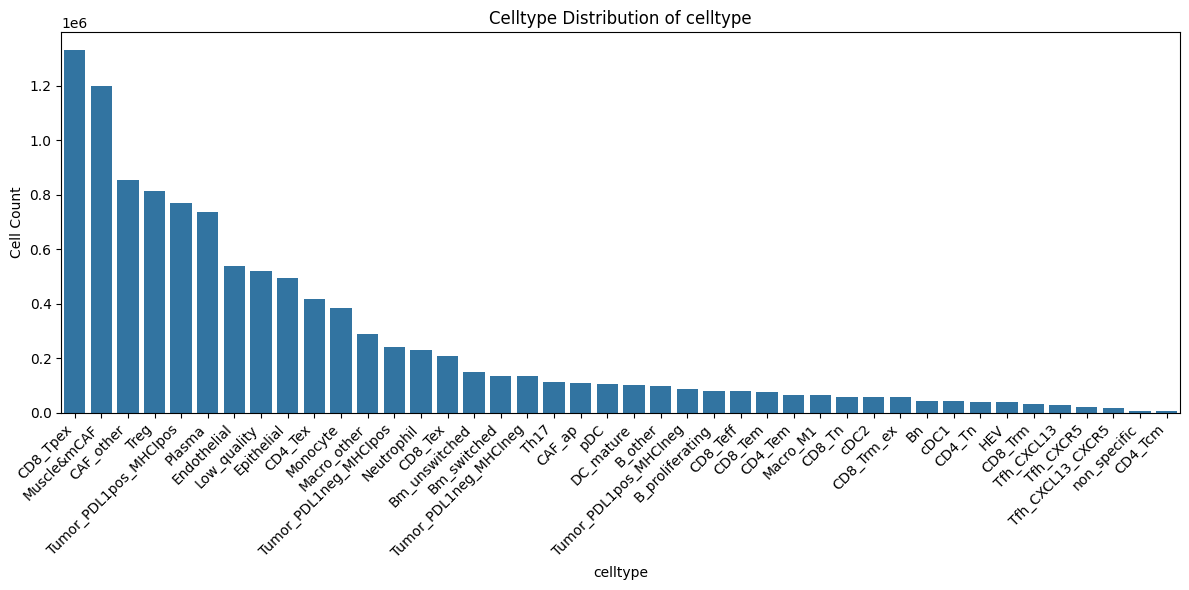

In [ ]:
plot_celltype_distribution(celltype, celltype_col='celltype')

The number of cells in celltype: 82805
The distribution of celltype: celltype
Epithelial               16508
Muscle&mCAF               7372
Plasma                    6308
CD8_Tpex                  5978
Monocyte                  4767
Treg                      4520
CAF_other                 4181
Tumor_PDL1pos_MHCIpos     3801
Tumor_PDL1neg_MHCIpos     3526
Macro_other               3355
Neutrophil                3075
Endothelial               2881
CD4_Tex                   2502
Low_quality               2476
CD8_Tex                   2310
Tumor_PDL1neg_MHCIneg     2263
Macro_M1                  1023
DC_mature                  747
pDC                        738
CD8_Teff                   723
CD8_Trm_ex                 444
B_other                    426
Bm_switched                376
Bm_unswitched              354
cDC2                       294
CD4_Tem                    274
CAF_ap                     223
cDC1                       219
Th17                       200
CD8_Tn                 

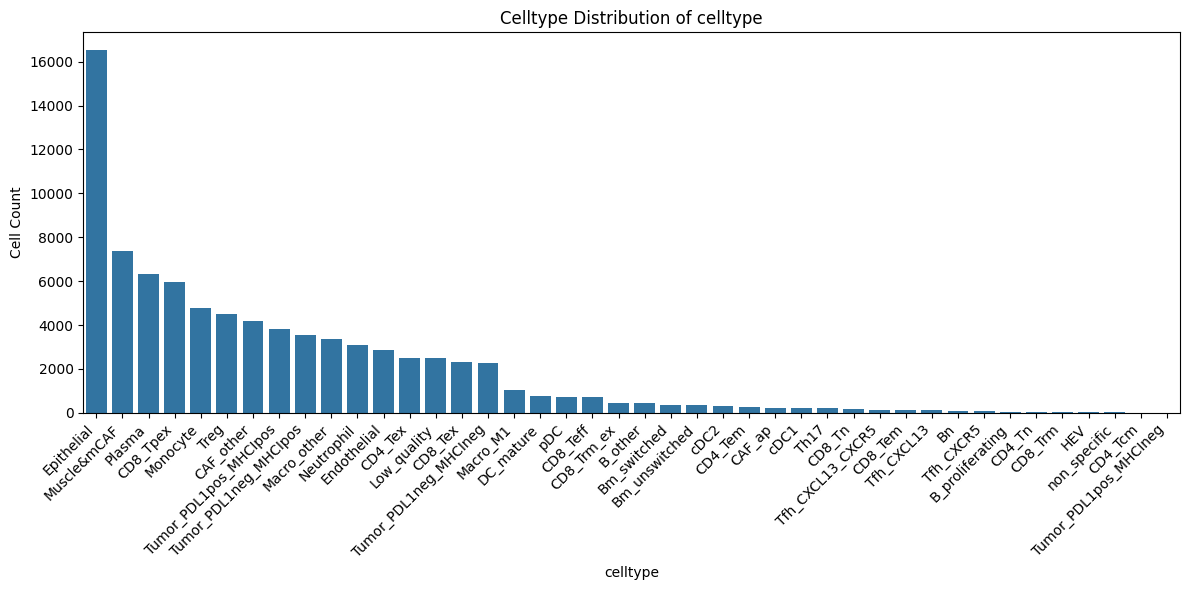

In [ ]:
plot_celltype_distribution(celltype_NCRT_tumor1, celltype_col='celltype')

In [ ]:
import pandas as pd
segment_data = 'NCRT_project - seg 1-14'
ncrt_anno_df1 = pd.read_csv(f'{path}Hist2Pheno/data/CODEX/ESCC/{therapy_data}/{segment_data}/{export_data}/NCRT-measurements-tumor1-14.csv')

print(ncrt_anno_df1.shape)
ncrt_anno_df1.head()

(870924, 58)


,Image,Object ID,Name,Class,Parent,ROI,Centroid X µm,Centroid Y µm,Detection probability,Nucleus: Area µm^2,...,PD-1: Cell: Mean,CD14: Cell: Mean,CD27: Cell: Mean,CD123: Cell: Mean,Granzyme B: Cell: Mean,c-PARP: Nucleus: Mean,CD38: Cell: Mean,LAG3: Cell: Mean,TCF-1: Nucleus: Mean,PD-L1: Cell: Mean
0,NCRT PCF.qptiff - resolution #1,e071bc4e-01bc-4831-a466-25be5330e3df,PathCellObject,NaN,tumor1,Polygon,4159.0,1.242,0.5100,3.9411,...,198.2059,188.0294,13.0588,12.4118,0.0000,1.6875,0.0000,33.8529,144.6875,33.2647
1,NCRT PCF.qptiff - resolution #1,99103727-0736-484a-93b0-f83efe823c03,PathCellObject,NaN,tumor1,Polygon,3970.5,2.817,0.8954,12.8580,...,198.8849,902.8584,39.9646,61.3628,0.1947,42.9184,7.4248,91.5575,178.2857,102.2389
2,NCRT PCF.qptiff - resolution #1,4882bef1-7690-443b-8e2c-512d3e81c77b,PathCellObject,NaN,tumor1,Polygon,4027.5,2.793,0.8912,30.7944,...,151.2155,2110.7844,15.8190,24.5216,0.0000,12.0635,0.3405,82.9138,138.8651,39.8319
3,NCRT PCF.qptiff - resolution #1,1e0d319a-d7c0-4c2a-85d1-08cfc6e42523,PathCellObject,NaN,tumor1,Polygon,4172.1,3.086,0.8751,28.3653,...,41.6081,88.2297,58.7523,6.5405,0.0000,1.8509,0.1171,22.0045,35.0351,11.9595
4,NCRT PCF.qptiff - resolution #1,ff987357-f306-42ab-8e03-233ac4f5e850,PathCellObject,NaN,tumor1,Polygon,3996.6,3.635,0.6372,30.5691,...,79.1639,1005.8992,7.1471,5.0840,0.0000,1.4878,0.0000,85.4328,33.2439,17.2185


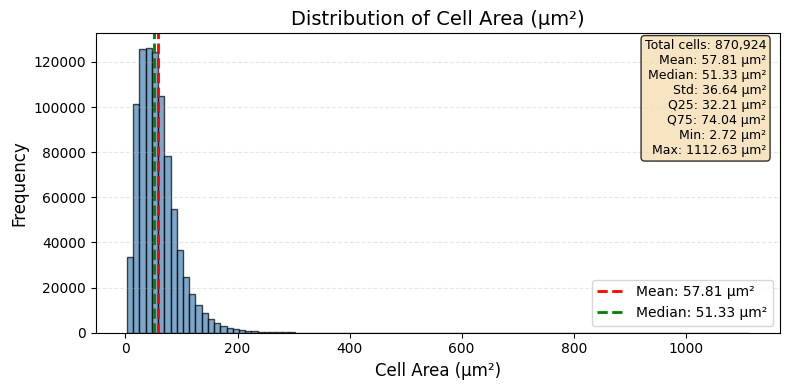


Summary Statistics for 'Cell: Area µm^2':
  Total cells: 870,924
  Mean: 57.81 µm²
  Median: 51.33 µm²
  Standard deviation: 36.64 µm²
  Range: [2.72, 1112.63] µm²
  IQR: [32.21, 74.04] µm²


In [ ]:
# Plot histogram of 'Cell: Area µm^2' distribution
plt.figure(figsize=(8, 4))

# Extract cell area data, removing NaN values
cell_area = ncrt_anno_df1['Cell: Area µm^2'].dropna()

# Create histogram
n, bins, patches = plt.hist(cell_area, bins=100, edgecolor='black', alpha=0.7, color='steelblue')

# Customize the plot
plt.xlabel('Cell Area (µm²)', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.title('Distribution of Cell Area (µm²)', fontsize=14)
plt.grid(True, alpha=0.3, linestyle='--', axis='y')

# Calculate and display statistics
mean_area = cell_area.mean()
median_area = cell_area.median()
std_area = cell_area.std()
q25 = cell_area.quantile(0.25)
q75 = cell_area.quantile(0.75)

# Add vertical lines for mean and median
plt.axvline(mean_area, color='red', linestyle='--', linewidth=2, label=f'Mean: {mean_area:.2f} µm²')
plt.axvline(median_area, color='green', linestyle='--', linewidth=2, label=f'Median: {median_area:.2f} µm²')
plt.legend(fontsize=10, loc='lower right')

# Add text box with statistics
stats_text = f'Total cells: {len(cell_area):,}\n'
stats_text += f'Mean: {mean_area:.2f} µm²\n'
stats_text += f'Median: {median_area:.2f} µm²\n'
stats_text += f'Std: {std_area:.2f} µm²\n'
stats_text += f'Q25: {q25:.2f} µm²\n'
stats_text += f'Q75: {q75:.2f} µm²\n'
stats_text += f'Min: {cell_area.min():.2f} µm²\n'
stats_text += f'Max: {cell_area.max():.2f} µm²'

plt.text(0.98, 0.98, stats_text, transform=plt.gca().transAxes,
         fontsize=9, verticalalignment='top', horizontalalignment='right',
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

plt.tight_layout()
plt.show()

# Print summary statistics
print(f"\nSummary Statistics for 'Cell: Area µm^2':")
print(f"  Total cells: {len(cell_area):,}")
print(f"  Mean: {mean_area:.2f} µm²")
print(f"  Median: {median_area:.2f} µm²")
print(f"  Standard deviation: {std_area:.2f} µm²")
print(f"  Range: [{cell_area.min():.2f}, {cell_area.max():.2f}] µm²")
print(f"  IQR: [{q25:.2f}, {q75:.2f}] µm²")

In [ ]:
print(ncrt_anno_df1.columns.tolist())
ncrt_anno_df1[['Centroid X µm', 'Centroid Y µm', 'Nucleus: Area µm^2', 'Cell: Area µm^2']]

['Image', 'Object ID', 'Name', 'Class', 'Parent', 'ROI', 'Centroid X µm', 'Centroid Y µm', 'Detection probability', 'Nucleus: Area µm^2', 'Cell: Area µm^2', 'Nucleus/Cell area ratio', 'DAPI: Nucleus: Mean', 'CLEC9A: Cell: Mean', 'CD31: Cell: Mean', 'CD4: Cell: Mean', 'CD23: Cell: Mean', 'DC-LAMP: Cell: Mean', 'CD86: Cell: Mean', 'CXCL13: Cell: Mean', 'CD20: Cell: Mean', 'CD68: Cell: Mean', 'CD45RO: Cell: Mean', 'CD11b: Cell: Mean', 'CD11c: Cell: Mean', 'TIM3: Cell: Mean', 'SMA: Cell: Mean', 'CD1c: Cell: Mean', 'CCL19: Cell: Mean', 'CD103: Cell: Mean', 'CXCR4: Cell: Mean', 'CXCR5: Cell: Mean', 'Pan-Cytokeratin: Cell: Mean', 'FOXP3: Nucleus: Mean', 'CD8: Cell: Mean', 'Vimentin: Cell: Mean', 'HLA-DR: Cell: Mean', 'HLA-A: Cell: Mean', 'CD15: Cell: Mean', 'TIGIT: Cell: Mean', 'CD21: Cell: Mean', 'PDPN: Cell: Mean', 'PNAd: Cell: Mean', 'IgD: Cell: Mean', 'Ki67: Nucleus: Mean', 'RORc: Nucleus: Mean', 'CCR7: Cell: Mean', 'CD45RA: Cell: Mean', 'PD-1: Cell: Mean', 'CD14: Cell: Mean', 'CD27: Cell

,Centroid X µm,Centroid Y µm,Nucleus: Area µm^2,Cell: Area µm^2
0,4159.0,1.242,3.9411,8.4927
1,3970.5,2.817,12.8580,28.5168
2,4027.5,2.793,30.7944,59.2573
3,4172.1,3.086,28.3653,56.1982
4,3996.6,3.635,30.5691,59.6716
...,...,...,...,...
870919,8826.6,18301.900,17.2448,38.2036
870920,8843.4,18315.000,10.8830,22.3320
870921,8850.7,18316.500,50.1130,102.9439
870922,8825.3,18317.100,44.7494,84.7496


In [ ]:
# print(len(ncrt_anno_df1.columns[12:ncrt_anno_df1.shape[1]]))
# ncrt_anno_df1.columns[12:ncrt_anno_df1.shape[1]]
## celltype_NCRT_tumor1

In [ ]:
# ## celltype_NCRT_tumor1
# celltype_NCRT_tumor1 = celltype[celltype['TumorID'] == 'NCRT_tumor1']
# print(celltype_NCRT_tumor1.columns.tolist())

# ## add 'Centroid X µm', 'Centroid Y µm' to celltype_NCRT_tumor1
# celltype_NCRT_tumor1 = merge_coordinates(celltype_NCRT_tumor1, ncrt_anno_df1, parent_value='tumor1')

# celltype_NCRT_tumor1.head()

In [ ]:
def get_celltype_subset(celltype_df, ncrt_anno_df, value, parent_value=None):
    # filter
    if parent_value is None:
        subset = celltype[celltype['TumorID'].str.contains(value)]
    else:
        subset = celltype[celltype['TumorID'] == value]
    print(subset.columns.tolist())
    # add 'Centroid X µm', 'Centroid Y µm'
    subset = merge_coordinates(subset, ncrt_anno_df, parent_value=parent_value)
    return subset

In [ ]:
## celltype_NCRT_tumor1
celltype_NCRT_tumor1 = get_celltype_subset(celltype, ncrt_anno_df1, value='NCRT_tumor1', parent_value='tumor1')
celltype_NCRT_tumor1.head()

['Unnamed: 0', 'CellID', 'TumorID', 'celltype']
Before filtering - ncrt_anno_df1 shape: (870924, 58)
Unique Parent values:
 ['tumor1' 'tumor2' 'tumor3' 'tumor4' 'tumor5' 'tumor6' 'tumor7' 'tumor8'
 'tumor9' 'tumor10' 'tumor11' 'tumor12' 'tumor13' 'tumor14']
After filtering for 'tumor1' - ncrt_anno_df1_tumor1 shape: (82805, 58)
Number of cells in tumor1: 82805

Shape of celltype_NCRT_tumor1 before merging: (82805, 4)
Shape of ncrt_anno_df1_tumor1: (82805, 58)
Shape of celltype_NCRT_tumor1 after merging: (82805, 6)

Columns after merging: ['Unnamed: 0', 'CellID', 'TumorID', 'celltype', 'Centroid X µm', 'Centroid Y µm']

Number of missing coordinates:
Centroid X µm    0
Centroid Y µm    0
dtype: int64

Successfully matched cells: 82805 / 82805 (100.00%)


,Unnamed: 0,CellID,TumorID,celltype,Centroid X µm,Centroid Y µm
0,NCRT_1,e071bc4e-01bc-4831-a466-25be5330e3df,NCRT_tumor1,CAF_other,4159.0,1.242
1,NCRT_2,99103727-0736-484a-93b0-f83efe823c03,NCRT_tumor1,Neutrophil,3970.5,2.817
2,NCRT_3,4882bef1-7690-443b-8e2c-512d3e81c77b,NCRT_tumor1,Monocyte,4027.5,2.793
3,NCRT_4,1e0d319a-d7c0-4c2a-85d1-08cfc6e42523,NCRT_tumor1,CAF_other,4172.1,3.086
4,NCRT_5,ff987357-f306-42ab-8e03-233ac4f5e850,NCRT_tumor1,Monocyte,3996.6,3.635


### Visualization CODEX

Number of valid data points: 82805
Number of cell types: 42


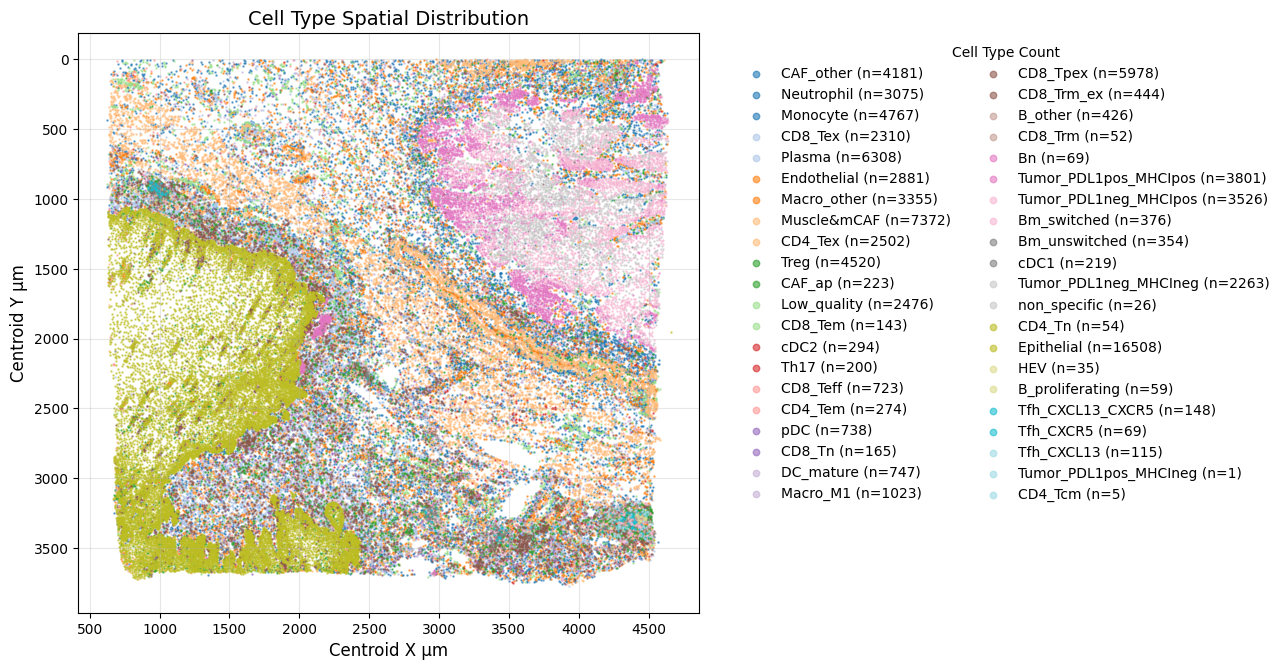

(<Figure size 1200x1000 with 1 Axes>,
 <Axes: title={'center': 'Cell Type Spatial Distribution'}, xlabel='Centroid X µm', ylabel='Centroid Y µm'>)

In [ ]:
## Plot the spatial distribution of cell types in celltype_NCRT_tumor1

# Remove rows with missing coordinates
celltype_NCRT_tumor1_clean = celltype_NCRT_tumor1.dropna(subset=['Centroid X µm', 'Centroid Y µm'])
print(f"Number of valid data points: {len(celltype_NCRT_tumor1_clean)}")
print(f"Number of cell types: {celltype_NCRT_tumor1_clean['celltype'].nunique()}")

plot_celltype_spatial_distribution(
    celltype_NCRT_tumor1_clean,
    x_col='Centroid X µm',
    y_col='Centroid Y µm',
    celltype_col='celltype',
    figsize=(12, 10),
    alpha=0.6,
    s=0.6
)

In [ ]:
## celltype_NCRT_tumor5
celltype_NCRT_tumor5 = get_celltype_subset(celltype, ncrt_anno_df1, value='NCRT_tumor5', parent_value='tumor5')
celltype_NCRT_tumor5.head()

['Unnamed: 0', 'CellID', 'TumorID', 'celltype']
Before filtering - ncrt_anno_df1 shape: (870924, 58)
Unique Parent values:
 ['tumor1' 'tumor2' 'tumor3' 'tumor4' 'tumor5' 'tumor6' 'tumor7' 'tumor8'
 'tumor9' 'tumor10' 'tumor11' 'tumor12' 'tumor13' 'tumor14']
After filtering for 'tumor5' - ncrt_anno_df1_tumor1 shape: (72694, 58)
Number of cells in tumor5: 72694

Shape of celltype_NCRT_tumor1 before merging: (72694, 4)
Shape of ncrt_anno_df1_tumor1: (72694, 58)
Shape of celltype_NCRT_tumor1 after merging: (72694, 6)

Columns after merging: ['Unnamed: 0', 'CellID', 'TumorID', 'celltype', 'Centroid X µm', 'Centroid Y µm']

Number of missing coordinates:
Centroid X µm    0
Centroid Y µm    0
dtype: int64

Successfully matched cells: 72694 / 72694 (100.00%)


,Unnamed: 0,CellID,TumorID,celltype,Centroid X µm,Centroid Y µm
0,NCRT_273970,7b8a886a-f8b4-4a96-bd83-e8fd2fc7b5b8,NCRT_tumor5,Epithelial,2200.3,4529.4
1,NCRT_273971,7bb61e8c-972b-45d9-878e-86d70ddc8cca,NCRT_tumor5,Epithelial,2037.6,4530.2
2,NCRT_273972,86f9e958-5411-42b9-b980-ca2c637f56d3,NCRT_tumor5,Epithelial,2085.6,4530.6
3,NCRT_273973,6bd27774-046b-427f-86ba-d8c73190af19,NCRT_tumor5,Epithelial,2021.7,4531.7
4,NCRT_273974,d7ec1b7b-5e77-4069-b60c-ec0df524302f,NCRT_tumor5,Epithelial,2058.1,4534.6


Number of valid data points: 72694
Number of cell types: 42


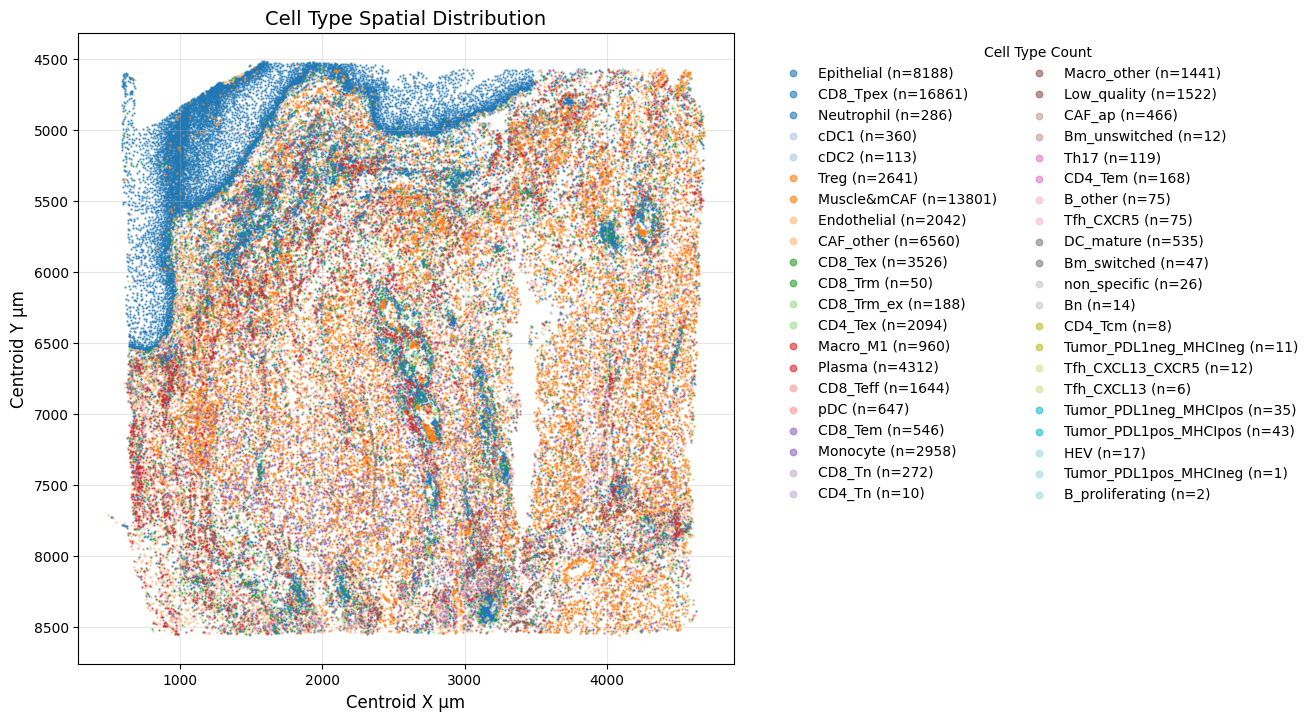

(<Figure size 1200x1000 with 1 Axes>,
 <Axes: title={'center': 'Cell Type Spatial Distribution'}, xlabel='Centroid X µm', ylabel='Centroid Y µm'>)

In [ ]:
## Plot the spatial distribution of cell types in celltype_NCRT_tumor1

# Remove rows with missing coordinates
celltype_NCRT_tumor5_clean = celltype_NCRT_tumor5.dropna(subset=['Centroid X µm', 'Centroid Y µm'])
print(f"Number of valid data points: {len(celltype_NCRT_tumor5_clean)}")
print(f"Number of cell types: {celltype_NCRT_tumor5_clean['celltype'].nunique()}")

plot_celltype_spatial_distribution(
    celltype_NCRT_tumor5_clean,
    x_col='Centroid X µm',
    y_col='Centroid Y µm',
    celltype_col='celltype',
    figsize=(12, 10),
    alpha=0.6,
    s=0.6
)

### Alignment HE

In [ ]:
## Transformation matrix between Xenium full resolution (DAPI) morphology image and the Xenium coordinate system.
## Get pixel size from HE image
he_path  = f'{path}Hist2Pheno/data/CODEX/ESCC/{therapy_data}/NCRT HE.qptiff'
pcf_path = f'{path}Hist2Pheno/data/CODEX/ESCC/{therapy_data}/NCRT PCF.qptiff'
print("HE path:", he_path)
print("PCF path:", pcf_path)
print("HE exists:", os.path.exists(he_path))
print("PCF exists:", os.path.exists(pcf_path))

HE path: /home/lingyu/data/Python/Collaborate/esccAI/data/NCRT/NCRT HE.qptiff
PCF path: /home/lingyu/data/Python/Collaborate/esccAI/data/NCRT/NCRT PCF.qptiff
HE exists: True
PCF exists: True


In [ ]:
## Transformation matrix exported from QuPath: transforms HE coordinates to PCF coordinates
## IMPORTANT: In QuPath, NCRT PCF.qptiff is the reference (front) and NCRT HE.qptiff is the target (back)
## Since we need PCF -> HE transformation, we need to INVERT this matrix

## Original matrix from QuPath (HE -> PCF):
qupath_matrix_HE2PCF = np.array(
    [
        [0.9838, 	 -0.0077,	 -5473.2797],
        [0.0077,	 0.9838,	 -2122.4005],
    ]
)
PCF2HE_transformation_NCRT = transformation_matrix_properties(qupath_matrix_HE2PCF)

Original QuPath matrix (HE -> PCF):
[[ 9.8380000e-01 -7.7000000e-03 -5.4732797e+03]
 [ 7.7000000e-03  9.8380000e-01 -2.1224005e+03]]

Matrix properties (HE -> PCF):
  Scale: 0.9838, Rotation: 0.4412°
  Translation: X=-5473.3, Y=-2122.4

Inverted matrix (PCF -> HE):
[[ 1.01640450e+00  7.95518869e-03  5.57995020e+03]
 [-7.95518869e-03  1.01640450e+00  2.11367644e+03]]

Matrix properties (PCF -> HE):
  Scale: 1.0164, Rotation: -0.4558°
  Translation: X=5580.0, Y=2113.7



Testing PCF -> HE transformation:
HE image dimensions: 47040 x 70560
PCF image dimensions: 35520 x 66240
Generated 1 test points, 1 within HE bounds


  Region 1 debug:
    PCF original: shape=(4000, 4000, 3), mean=5.4, max=90, min=0
    PCF warped: shape=(4098, 4097, 3), dtype=uint8, mean=0.0, max=0, min=0
    HE region: shape=(4098, 4097, 3), dtype=uint8, mean=217.2, max=255, min=0
    Overlay: shape=(4098, 4097, 3), mean=99.8, max=127
Created visualization with 1 regions
Figure size: [18.  6.]


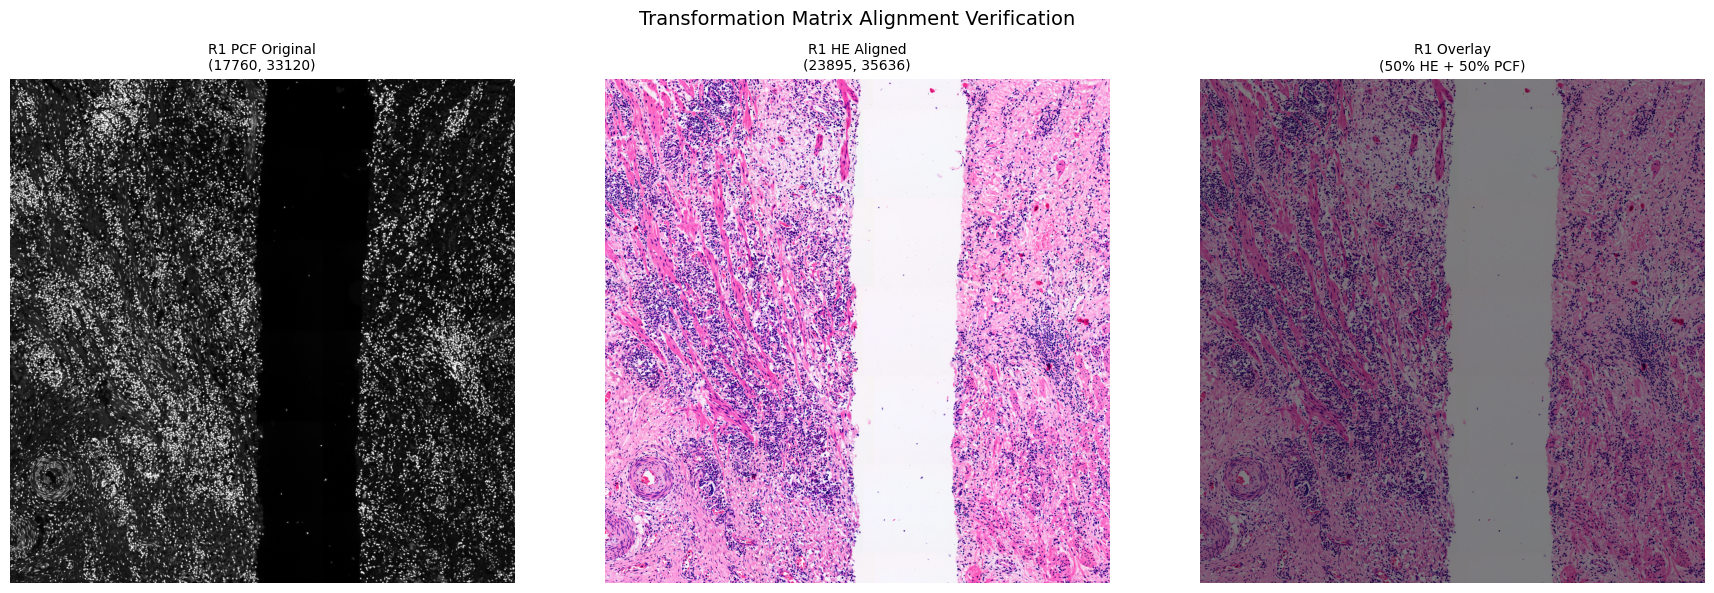

✓ Visualization displayed

Check the overlay images above:
  - If images are well-aligned: the overlay should show clear, sharp structures
  - If images are misaligned: you may see double/blurry structures


In [ ]:
## Verify current transformation matrix alignment
## Note: QuPath shows HE->PCF, we need PCF->HE)

print("\n" + "="*60)
print("Testing PCF -> HE transformation:")
print("="*60)

fig_verify = verify_transformation_alignment(he_path, pcf_path, PCF2HE_transformation_NCRT, 
                                                test_regions=1, region_size=4000)
if fig_verify is not None:
    plt.show()
    print("✓ Visualization displayed")
    print("\nCheck the overlay images above:")
    print("  - If images are well-aligned: the overlay should show clear, sharp structures")
    print("  - If images are misaligned: you may see double/blurry structures")
else:
    print("✗ Failed to create visualization")

### Coordinates transform: PCF -> HE

In [ ]:
## Convert coordinates to pixel coordinates
## Based on pixel_size_um from Cell 26, convert PCF coordinates to pixel coordinates
## Then use PCF2HE_transformation_NCRT to convert to HE pixel coordinates

# Convert PCF coordinates (µm) to PCF pixel coordinates
# The 'Centroid X µm' and 'Centroid Y µm' columns are in micrometers
# Divide by pixel_size_um to get pixel coordinates
segment_path = f'{path}Hist2Pheno/data/CODEX/ESCC/{therapy_data}/{segment_data}'
pixel_size_um, width_PCF, height_PCF = get_pixel_size_from_server_json(segment_path)
print(f"Converting PCF coordinates (µm) to PCF pixel coordinates...")
print(f"Using pixel_size_um = {pixel_size_um}")
print("="*60)

celltype_pixel_NCRT_tumor1 = add_pixel_coords(celltype_NCRT_tumor1, pixel_size_um, PCF2HE_transformation_NCRT)
print("Cell numbers with NCRT:", celltype_pixel_NCRT_tumor1.shape[0])
celltype_pixel_NCRT_tumor1.head()


pixel_size_um read from server.json: 0.508248 µm
width read from server.json: 35520
height read from server.json: 66240
Converting PCF coordinates (µm) to PCF pixel coordinates...
Using pixel_size_um = 0.5082483404568044
Added columns: X_pix_PCF, Y_pix_PCF
X_pix_PCF range: [1221.39, 9166.98]
Y_pix_PCF range: [2.25, 7423.93]

Converting PCF pixel coordinates to HE pixel coordinates...
Added columns: X_pix_HE, Y_pix_HE
X_pix_HE range: [6835.66, 14927.86]
Y_pix_HE range: [2047.09, 9597.83]

Updated celltype_NCRT_tumor1 columns (4 pixel coordinate columns added at the end):
['Unnamed: 0', 'CellID', 'TumorID', 'celltype', 'Centroid X µm', 'Centroid Y µm', 'X_pix_PCF', 'Y_pix_PCF', 'X_pix_HE', 'Y_pix_HE']
Cell numbers with NCRT: 82805


,Unnamed: 0,CellID,TumorID,celltype,Centroid X µm,Centroid Y µm,X_pix_PCF,Y_pix_PCF,X_pix_HE,Y_pix_HE
0,NCRT_1,e071bc4e-01bc-4831-a466-25be5330e3df,NCRT_tumor1,CAF_other,4159.0,1.242,8183.007536,2.443687,13897.215308,2051.062848
1,NCRT_2,99103727-0736-484a-93b0-f83efe823c03,NCRT_tumor1,Neutrophil,3970.5,2.817,7812.125853,5.542566,13520.274149,2057.162996
2,NCRT_3,4882bef1-7690-443b-8e2c-512d3e81c77b,NCRT_tumor1,Monocyte,4027.5,2.793,7924.275751,5.495345,13634.263435,2056.222826
3,NCRT_4,1e0d319a-d7c0-4c2a-85d1-08cfc6e42523,NCRT_tumor1,CAF_other,4172.1,3.086,8208.782337,6.071835,13923.441794,2054.545470
4,NCRT_5,ff987357-f306-42ab-8e03-233ac4f5e850,NCRT_tumor1,Monocyte,3996.6,3.635,7863.478701,7.152015,13572.482218,2058.390326


codex_celltype
he_cell_coords

In [ ]:
segment_data = 'NCRT_project - seg 15-28'
ncrt_anno_df2 = pd.read_csv(f'{path}Hist2Pheno/data/CODEX/ESCC/{therapy_data}/{segment_data}/{export_data}/NCRT-measurements-tumor-15-28.csv')
ncrt_anno_df = pd.concat([ncrt_anno_df1, ncrt_anno_df2], ignore_index=True)
print("Cell numbers of 1-14:", ncrt_anno_df1.shape)
print("Cell numbers of 15-28:", ncrt_anno_df2.shape)
print("Cell numbers of 1-28:", ncrt_anno_df.shape)
# ncrt_anno_df.head()

Cell numbers of 1-14: (870924, 58)
Cell numbers of 15-28: (1021484, 58)
Cell numbers of 1-28: (1892408, 58)


In [ ]:
## celltype_NCRT
celltype_NCRT = get_celltype_subset(celltype, ncrt_anno_df, value='NCRT', parent_value=None)
celltype_NCRT.head()

['Unnamed: 0', 'CellID', 'TumorID', 'celltype']
Dont filtering - parent value: 'Parent' column
Available columns: ['Image', 'CellID', 'Name', 'Class', 'Parent', 'ROI', 'Centroid X µm', 'Centroid Y µm', 'Detection probability', 'Nucleus: Area µm^2']
Shape of celltype_NCRT_tumor1 after merging: (1892408, 6)

Columns after merging: ['Unnamed: 0', 'CellID', 'TumorID', 'celltype', 'Centroid X µm', 'Centroid Y µm']

Number of missing coordinates:
Centroid X µm    0
Centroid Y µm    0
dtype: int64

Successfully matched cells: 1892408 / 1892408 (100.00%)


,Unnamed: 0,CellID,TumorID,celltype,Centroid X µm,Centroid Y µm
0,NCRT_1,e071bc4e-01bc-4831-a466-25be5330e3df,NCRT_tumor1,CAF_other,4159.0,1.242
1,NCRT_2,99103727-0736-484a-93b0-f83efe823c03,NCRT_tumor1,Neutrophil,3970.5,2.817
2,NCRT_3,4882bef1-7690-443b-8e2c-512d3e81c77b,NCRT_tumor1,Monocyte,4027.5,2.793
3,NCRT_4,1e0d319a-d7c0-4c2a-85d1-08cfc6e42523,NCRT_tumor1,CAF_other,4172.1,3.086
4,NCRT_5,ff987357-f306-42ab-8e03-233ac4f5e850,NCRT_tumor1,Monocyte,3996.6,3.635


In [ ]:
celltype_pixel_NCRT = add_pixel_coords(celltype_NCRT, pixel_size_um, PCF2HE_transformation_NCRT)
print("Cell numbers with NCRT:", celltype_pixel_NCRT.shape[0])
print(celltype_pixel_NCRT.shape)
celltype_pixel_NCRT.head()

Added columns: X_pix_PCF, Y_pix_PCF
X_pix_PCF range: [966.91, 35374.05]
Y_pix_PCF range: [2.25, 64430.12]

Converting PCF pixel coordinates to HE pixel coordinates...


Added columns: X_pix_HE, Y_pix_HE
X_pix_HE range: [6683.43, 41626.72]
Y_pix_HE range: [1841.47, 67427.28]

Updated celltype_NCRT_tumor1 columns (4 pixel coordinate columns added at the end):
['Unnamed: 0', 'CellID', 'TumorID', 'celltype', 'Centroid X µm', 'Centroid Y µm', 'X_pix_PCF', 'Y_pix_PCF', 'X_pix_HE', 'Y_pix_HE']
Cell numbers with NCRT: 1892408
(1892408, 10)


,Unnamed: 0,CellID,TumorID,celltype,Centroid X µm,Centroid Y µm,X_pix_PCF,Y_pix_PCF,X_pix_HE,Y_pix_HE
0,NCRT_1,e071bc4e-01bc-4831-a466-25be5330e3df,NCRT_tumor1,CAF_other,4159.0,1.242,8183.007536,2.443687,13897.215308,2051.062848
1,NCRT_2,99103727-0736-484a-93b0-f83efe823c03,NCRT_tumor1,Neutrophil,3970.5,2.817,7812.125853,5.542566,13520.274149,2057.162996
2,NCRT_3,4882bef1-7690-443b-8e2c-512d3e81c77b,NCRT_tumor1,Monocyte,4027.5,2.793,7924.275751,5.495345,13634.263435,2056.222826
3,NCRT_4,1e0d319a-d7c0-4c2a-85d1-08cfc6e42523,NCRT_tumor1,CAF_other,4172.1,3.086,8208.782337,6.071835,13923.441794,2054.545470
4,NCRT_5,ff987357-f306-42ab-8e03-233ac4f5e850,NCRT_tumor1,Monocyte,3996.6,3.635,7863.478701,7.152015,13572.482218,2058.390326


celltype_pixel_NCRT.to_csv(f'{path}Hist2Pheno/data/CODEX/ESCC/{therapy_data}/NCRT_measurements_tumor_CellPixCoords.csv')    # only NCRT

In [ ]:
## Save CellPixCoords
# celltype_pixel_NCRT.to_csv(f'{path}Hist2Pheno/data/CODEX/ESCC/he_cell_coords/NCRT_CellPixCoords.csv')

In [ ]:
## Save CellPixCoords
# celltype_pixel_NCRT_tumor1.to_csv(f'{path}Hist2Pheno/data/CODEX/ESCC/he_cell_coords/NCRT_CellPixCoords_tumor1.csv')

## HIPT

<!-- ## Option A: Using HIPT (recommended for quick start, no token required) -->
python ./demo/Image_feature_extraction.py \
   --dataset NPC \
   --position_path FineST_tutorial_data/spatial/tissue_positions_list.csv \
   --rawimage_path FineST_tutorial_data/20210809-C-AH4199551.tif \
   --scale_image False \
   --method HIPT \
   --patch_size 64 \
   --output_img FineST_tutorial_data/ImgEmbeddings/pth_64_16_image \
   --output_pth FineST_tutorial_data/ImgEmbeddings/pth_64_16 \
   --logging FineST_tutorial_data/ImgEmbeddings/Logging/ \
   --scale 0.5  # default is 0.5

In [5]:
## Load celltype_pixel_NCRT
path = '/home/lingyu/ssd2/Python/'
therapy_data = 'NCRT'
import pandas as pd
celltype_pixel_NCRT = pd.read_csv(f'{path}Hist2Pheno/data/CODEX/ESCC/he_cell_coords/NCRT_CellPixCoords.csv')
celltype_pixel_NCRT.head()

,Unnamed: 0.1,Unnamed: 0,CellID,TumorID,celltype,Centroid X µm,Centroid Y µm,X_pix_PCF,Y_pix_PCF,X_pix_HE,Y_pix_HE
0,0,NCRT_1,e071bc4e-01bc-4831-a466-25be5330e3df,NCRT_tumor1,CAF_other,4159.0,1.242,8183.007536,2.443687,13897.215308,2051.062848
1,1,NCRT_2,99103727-0736-484a-93b0-f83efe823c03,NCRT_tumor1,Neutrophil,3970.5,2.817,7812.125853,5.542566,13520.274149,2057.162996
2,2,NCRT_3,4882bef1-7690-443b-8e2c-512d3e81c77b,NCRT_tumor1,Monocyte,4027.5,2.793,7924.275751,5.495345,13634.263435,2056.222826
3,3,NCRT_4,1e0d319a-d7c0-4c2a-85d1-08cfc6e42523,NCRT_tumor1,CAF_other,4172.1,3.086,8208.782337,6.071835,13923.441794,2054.545470
4,4,NCRT_5,ff987357-f306-42ab-8e03-233ac4f5e850,NCRT_tumor1,Monocyte,3996.6,3.635,7863.478701,7.152015,13572.482218,2058.390326


In [6]:
celltype_pixel_NCRT.rename(columns={'X_pix_HE': 'pxl_row_in_fullres', 'Y_pix_HE': 'pxl_col_in_fullres'}, inplace=True)
celltype_pixel_NCRT.head()
## save celltype_pixel_NCRT for HIPT
# celltype_pixel_NCRT.to_csv(f'{path}Hist2Pheno/data/CODEX/ESCC/he_cell_coords/NCRT_CellPixCoords_HIPT.csv')

,Unnamed: 0.1,Unnamed: 0,CellID,TumorID,celltype,Centroid X µm,Centroid Y µm,X_pix_PCF,Y_pix_PCF,pxl_row_in_fullres,pxl_col_in_fullres
0,0,NCRT_1,e071bc4e-01bc-4831-a466-25be5330e3df,NCRT_tumor1,CAF_other,4159.0,1.242,8183.007536,2.443687,13897.215308,2051.062848
1,1,NCRT_2,99103727-0736-484a-93b0-f83efe823c03,NCRT_tumor1,Neutrophil,3970.5,2.817,7812.125853,5.542566,13520.274149,2057.162996
2,2,NCRT_3,4882bef1-7690-443b-8e2c-512d3e81c77b,NCRT_tumor1,Monocyte,4027.5,2.793,7924.275751,5.495345,13634.263435,2056.222826
3,3,NCRT_4,1e0d319a-d7c0-4c2a-85d1-08cfc6e42523,NCRT_tumor1,CAF_other,4172.1,3.086,8208.782337,6.071835,13923.441794,2054.545470
4,4,NCRT_5,ff987357-f306-42ab-8e03-233ac4f5e850,NCRT_tumor1,Monocyte,3996.6,3.635,7863.478701,7.152015,13572.482218,2058.390326


In [ ]:
# ## Load celltype_pixel_NCRT
# path = '/home/lingyu/ssd2/Python/'
# therapy_data = 'NCRT'
# celltype_pixel_NCRT = pd.read_csv(f'{path}Hist2Pheno/data/CODEX/ESCC/he_cell_coords/NCRT_CellPixCoords_tumor1.csv')
# # celltype_pixel_NCRT.head()
# celltype_pixel_NCRT.rename(columns={'X_pix_HE': 'pxl_row_in_fullres', 'Y_pix_HE': 'pxl_col_in_fullres'}, inplace=True)
# # celltype_pixel_NCRT.head()
# celltype_pixel_NCRT.to_csv(f'{path}Hist2Pheno/data/CODEX/ESCC/he_cell_coords/NCRT_CellPixCoords_tumor1_HIPT.csv')

In [ ]:
# ## Option A: Using HIPT (recommended for quick start, no token required)
# %cd /home/lingyu/data/Python/Collaborate/esccAI/
# !python code/Image_feature_extraction.py \
#    --dataset sc_NCRT \
#    --position_path data/he_cell_coords/NCRT_CellPixCoords_tumor1_HIPT.csv \
#    --rawimage_path data/NCRT/NCRT_HE.qptiff \
#    --scale_image False \
#    --method HIPT \
#    --patch_size 16 \
#    --output_img data/NCRT/ImgEmbeddings_tumor1/sc_pth_16_16_image \
#    --output_pth data/NCRT/ImgEmbeddings_tumor1/sc_pth_16_16 \
#    --logging data/NCRT/ImgEmbeddings_tumor1/ \
#    --scale 0.5  

/data/research/esccAI


[2026-02-26 15:12:12] INFO - Using device: cuda:0
[2026-02-26 15:12:12] INFO - Loaded CSV with shape: (82805, 12)
[2026-02-26 15:12:12] INFO - tissue_position: 
    Unnamed: 0.2  Unnamed: 0.1  ... pxl_row_in_fullres pxl_col_in_fullres
0             0             0  ...       13897.215308        2051.062848
1             1             1  ...       13520.274149        2057.162996
2             2             2  ...       13634.263435        2056.222826
3             3             3  ...       13923.441794        2054.545470
4             4             4  ...       13572.482218        2058.390326

[5 rows x 12 columns]
[2026-02-26 15:12:12] INFO - tissue_position number: 82805
[2026-02-26 15:12:12] INFO - tissue_position range: 14927.859760810934 9597.832102767605
[2026-02-26 15:12:12] INFO - Loading image at original resolution (no scaling)
[2026-02-26 15:12:12] INFO - image_width, image_height: 47040, 70560
[2026-02-26 15:12:39] INFO - patch_name: 0, sc_NCRT_13897.215307679162_2051.06284

## Cell Type Classification Model

Build a multi-class classification model using:
- **X (Input)**: HIPT embeddings from .pth files (82805 cells)
- **Y (Ground Truth)**: Cell types from celltype_pixel_NCRT_tumor1
- **Model**: Multi-Layer Perceptron (MLP) Neural Network
- **Train/Test Split**: 70% / 30%
- **Hyperparameter Tuning**: 5-fold cross-validation

In [7]:
# Load required libraries for machine learning
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold, GridSearchCV
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (classification_report, confusion_matrix, accuracy_score, 
                            precision_score, recall_score, f1_score, 
                            precision_recall_fscore_support)
import seaborn as sns
import torch
from pathlib import Path
from tqdm import tqdm
import re

print("Libraries imported successfully")

Libraries imported successfully


In [8]:
# Load celltype data (ground truth Y)
# Use celltype_pixel_NCRT_tumor1 which has X_pix_HE and Y_pix_HE coordinates
print("Loading celltype data...")

# Check if celltype_pixel_NCRT_tumor1 exists, if not, create it
if 'celltype_pixel_NCRT_tumor1' not in globals():
    print("  celltype_pixel_NCRT_tumor1 not found, loading from file or creating...")
    # Try to load from CSV if exists
    tumor1_coords_path = f'{path}Hist2Pheno/data/CODEX/ESCC/he_cell_coords/NCRT_CellPixCoords_tumor1.csv'
    if os.path.exists(tumor1_coords_path):
        celltype_pixel_NCRT_tumor1 = pd.read_csv(tumor1_coords_path)
        print(f"  Loaded from {tumor1_coords_path}")
    else:
        # Create it from celltype_NCRT_tumor1 if available
        if 'celltype_NCRT_tumor1' in globals():
            print("  Creating celltype_pixel_NCRT_tumor1 from celltype_NCRT_tumor1...")
            celltype_pixel_NCRT_tumor1 = add_pixel_coords(celltype_NCRT_tumor1, pixel_size_um, PCF2HE_transformation_NCRT)
        else:
            raise ValueError("celltype_NCRT_tumor1 not found. Please run Cell 20 first.")

print(f"  Loaded {len(celltype_pixel_NCRT_tumor1)} cells")
print(f"  Columns: {celltype_pixel_NCRT_tumor1.columns.tolist()}")
print(f"  Cell types: {celltype_pixel_NCRT_tumor1['celltype'].nunique()} unique types")
print(f"  Cell type distribution:\n{celltype_pixel_NCRT_tumor1['celltype'].value_counts()}")

Loading celltype data...
  celltype_pixel_NCRT_tumor1 not found, loading from file or creating...
  Loaded from /home/lingyu/data/Python/Collaborate/esccAI/data/he_cell_coords/NCRT_CellPixCoords_tumor1.csv
  Loaded 82805 cells
  Columns: ['Unnamed: 0.1', 'Unnamed: 0', 'CellID', 'TumorID', 'celltype', 'Centroid X µm', 'Centroid Y µm', 'X_pix_PCF', 'Y_pix_PCF', 'X_pix_HE', 'Y_pix_HE']
  Cell types: 42 unique types
  Cell type distribution:
celltype
Epithelial               16508
Muscle&mCAF               7372
Plasma                    6308
CD8_Tpex                  5978
Monocyte                  4767
Treg                      4520
CAF_other                 4181
Tumor_PDL1pos_MHCIpos     3801
Tumor_PDL1neg_MHCIpos     3526
Macro_other               3355
Neutrophil                3075
Endothelial               2881
CD4_Tex                   2502
Low_quality               2476
CD8_Tex                   2310
Tumor_PDL1neg_MHCIneg     2263
Macro_M1                  1023
DC_mature             

In [9]:
# Load HIPT embeddings from .pth files (Input X)
print("Loading HIPT embeddings from .pth files...")

embedding_dir = Path(f'{path}Hist2Pheno/data/CODEX/ESCC/{therapy_data}/ImgEmbeddings_tumor1/sc_pth_16_16')
pth_files = list(embedding_dir.glob('*.pth'))

print(f"  Found {len(pth_files)} .pth files")

# Extract coordinates from filenames and load embeddings
embeddings_dict = {}
coords_dict = {}
failed_files = []

print("  Loading embeddings...")
for pth_file in tqdm(pth_files, desc="Loading .pth files"):
    # Extract coordinates from filename: sc_NCRT_{x}_{y}.pth
    match = re.search(r'sc_NCRT_([\d.]+)_([\d.]+)\.pth', pth_file.name)
    if match:
        x_coord = float(match.group(1))
        y_coord = float(match.group(2))
        
        # Load embedding tensor
        try:
            embedding_data = torch.load(pth_file, map_location='cpu')
            
            # Handle different formats:
            # 1. Tuple of tensors (from torch.split) - this is the expected format for HIPT
            # 2. Single tensor
            # 3. List
            # 4. Numpy array
            
            if isinstance(embedding_data, tuple):
                # For HIPT: subtensors_list is a tuple of tensors, each is [1, 384]
                # Concatenate all tensors in the tuple and flatten
                tensor_list = []
                for t in embedding_data:
                    if isinstance(t, torch.Tensor):
                        # Convert to numpy and squeeze dimensions
                        t_np = t.detach().cpu().numpy()
                        tensor_list.append(t_np.flatten())
                    else:
                        tensor_list.append(np.array(t).flatten())
                embedding = np.concatenate(tensor_list)
                
            elif isinstance(embedding_data, torch.Tensor):
                # Single tensor - convert to numpy
                embedding = embedding_data.detach().cpu().numpy()
                # Handle 0-dimensional tensors (scalars)
                if embedding.ndim == 0:
                    embedding = np.array([embedding.item()])
                # Flatten if needed
                if embedding.ndim > 1:
                    embedding = embedding.flatten()
                    
            elif isinstance(embedding_data, list):
                # List of tensors or arrays
                tensor_list = []
                for item in embedding_data:
                    if isinstance(item, torch.Tensor):
                        tensor_list.append(item.detach().cpu().numpy().flatten())
                    else:
                        tensor_list.append(np.array(item).flatten())
                embedding = np.concatenate(tensor_list)
                
            else:
                # Try to convert to numpy array
                try:
                    embedding = np.array(embedding_data)
                    if embedding.ndim == 0:
                        embedding = np.array([embedding.item()])
                    if embedding.ndim > 1:
                        embedding = embedding.flatten()
                except Exception as e:
                    raise ValueError(f"Cannot convert embedding to numpy array: {e}")
            
            # Ensure embedding is 1D
            if embedding.ndim > 1:
                embedding = embedding.flatten()
            
            # Store embedding
            coords_dict[(x_coord, y_coord)] = embedding
            embeddings_dict[(x_coord, y_coord)] = embedding
            
        except Exception as e:
            failed_files.append((pth_file.name, str(e)))
            if len(failed_files) <= 5:  # Only print first 5 errors
                print(f"  Warning: Failed to load {pth_file.name}: {e}")
            continue

print(f"  Successfully loaded {len(embeddings_dict)} embeddings")
if len(failed_files) > 5:
    print(f"  ... and {len(failed_files) - 5} more files failed to load")
if len(failed_files) > 0:
    print(f"  Total failed: {len(failed_files)} files")

if len(embeddings_dict) > 0:
    sample_emb = list(embeddings_dict.values())[0]
    print(f"  Embedding dimension: {sample_emb.shape}")
    print(f"  Sample embedding dtype: {sample_emb.dtype}")
else:
    print("  ERROR: No embeddings loaded! Please check the .pth files.")

Loading HIPT embeddings from .pth files...
  Found 82805 .pth files
  Loading embeddings...


Loading .pth files: 100%|██████████| 82805/82805 [00:15<00:00, 5261.42it/s]

  Successfully loaded 82805 embeddings
  Embedding dimension: (384,)
  Sample embedding dtype: float32


In [ ]:
# Match embeddings with celltype data by coordinates
# Check if matched data already exists
import pickle
matched_data_path = f'{path}Hist2Pheno/data/CODEX/ESCC/{therapy_data}/matched_data_tumor1.pkl'
matched_features_path = f'{path}Hist2Pheno/data/CODEX/ESCC/{therapy_data}/matched_features_tumor1.npz'
# os.remove(matched_features_path)    # remove matched_features_tumor1.npz

# Try to load pre-saved matched data
if os.path.exists(matched_features_path):
    print("Loading pre-saved matched data...")
    loaded_data = np.load(matched_features_path)
    X = loaded_data['X']
    y = loaded_data['y']
    print(f"  ✓ Loaded from {matched_features_path}")
    print(f"  X shape: {X.shape}")
    print(f"  y shape: {y.shape}")
    print(f"  Number of classes: {len(np.unique(y))}")
    print(f"  Classes: {sorted(np.unique(y))}")
else:
    print("Matching embeddings with celltype data (this may take a few minutes)...")
    
    # Create a matching function with tolerance for floating point differences
    def find_matching_coord(target_x, target_y, coords_dict, tolerance=0.1):
        """Find matching coordinate in coords_dict within tolerance."""
        for (x, y), emb in coords_dict.items():
            if abs(x - target_x) < tolerance and abs(y - target_y) < tolerance:
                return (x, y)
        return None
    
    # Match data
    matched_data = []
    celltype_pixel_NCRT_tumor1_matched = celltype_pixel_NCRT_tumor1.copy()
    
    for idx, row in tqdm(celltype_pixel_NCRT_tumor1.iterrows(), 
                         total=len(celltype_pixel_NCRT_tumor1), 
                         desc="Matching coordinates"):
        x_coord = row['X_pix_HE']
        y_coord = row['Y_pix_HE']
        
        # Try to find matching embedding
        match_key = find_matching_coord(x_coord, y_coord, embeddings_dict, tolerance=0.1)
        
        if match_key is not None:
            embedding = embeddings_dict[match_key]
            matched_data.append({
                'idx': idx,
                'celltype': row['celltype'],
                'X_pix_HE': x_coord,
                'Y_pix_HE': y_coord,
                'embedding': embedding
            })
    
    print(f"  Matched {len(matched_data)} cells out of {len(celltype_pixel_NCRT_tumor1)}")
    print(f"  Match rate: {len(matched_data)/len(celltype_pixel_NCRT_tumor1)*100:.2f}%")
    
    # Create feature matrix X and label vector y
    X = np.array([item['embedding'] for item in matched_data])
    y = np.array([item['celltype'] for item in matched_data])
    
    print(f"\nData shape:")
    print(f"  X (features): {X.shape}")
    print(f"  y (labels): {y.shape}")
    print(f"  Number of classes: {len(np.unique(y))}")
    print(f"  Classes: {sorted(np.unique(y))}")
    
    # Save matched data for future use
    print(f"\nSaving matched data for future use...")
    # Save X and y as numpy arrays (faster to load)
    np.savez_compressed(matched_features_path, X=X, y=y)
    print(f"  ✓ Saved features to {matched_features_path}")
    
    # Optionally save full matched_data as pickle (for debugging)
    # with open(matched_data_path, 'wb') as f:
    #     pickle.dump(matched_data, f)
    # print(f"  ✓ Saved full matched_data to {matched_data_path}")

Matching embeddings with celltype data (this may take a few minutes)...


Matching coordinates:   0%|          | 12/82805 [00:00<11:54, 115.81it/s]

Matching coordinates:  45%|████▌     | 37660/82805 [02:58<03:08, 239.32it/s]

In [11]:
# Encode labels and prepare data
print("Preparing data for modeling...")

# Encode cell types to numeric labels
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)
class_names = label_encoder.classes_

print(f"  Encoded {len(class_names)} cell types")
print(f"  Class names: {class_names}")

# Check for classes with very few samples (might need to filter)
class_counts = pd.Series(y).value_counts()
print(f"\n  Class distribution:")
print(class_counts)

# Filter out classes with very few samples (optional, adjust threshold as needed)
min_samples_per_class = 10
valid_classes = class_counts[class_counts >= min_samples_per_class].index
valid_mask = pd.Series(y).isin(valid_classes)

if valid_mask.sum() < len(y):
    print(f"\n  Filtering out classes with < {min_samples_per_class} samples...")
    print(f"  Before filtering: {len(y)} samples")
    X = X[valid_mask.values]
    y = y[valid_mask.values]
    y_encoded = label_encoder.transform(y)
    print(f"  After filtering: {len(y)} samples")
    print(f"  Remaining classes: {len(np.unique(y))}")

# Train/Test split (70% / 30%)
X_train, X_test, y_train, y_test, y_train_encoded, y_test_encoded = train_test_split(
    X, y, y_encoded, 
    test_size=0.3, 
    random_state=42, 
    stratify=y_encoded  # Ensure balanced class distribution
)

print(f"\nTrain/Test split:")
print(f"  Training set: {X_train.shape[0]} samples")
print(f"  Test set: {X_test.shape[0]} samples")
print(f"  Feature dimension: {X_train.shape[1]}")

# Standardize features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"  Features standardized")

Preparing data for modeling...
  Encoded 42 cell types
  Class names: ['B_other' 'B_proliferating' 'Bm_switched' 'Bm_unswitched' 'Bn' 'CAF_ap'
 'CAF_other' 'CD4_Tcm' 'CD4_Tem' 'CD4_Tex' 'CD4_Tn' 'CD8_Teff' 'CD8_Tem'
 'CD8_Tex' 'CD8_Tn' 'CD8_Tpex' 'CD8_Trm' 'CD8_Trm_ex' 'DC_mature'
 'Endothelial' 'Epithelial' 'HEV' 'Low_quality' 'Macro_M1' 'Macro_other'
 'Monocyte' 'Muscle&mCAF' 'Neutrophil' 'Plasma' 'Tfh_CXCL13'
 'Tfh_CXCL13_CXCR5' 'Tfh_CXCR5' 'Th17' 'Treg' 'Tumor_PDL1neg_MHCIneg'
 'Tumor_PDL1neg_MHCIpos' 'Tumor_PDL1pos_MHCIneg' 'Tumor_PDL1pos_MHCIpos'
 'cDC1' 'cDC2' 'non_specific' 'pDC']

  Class distribution:
Epithelial               16508
Muscle&mCAF               7372
Plasma                    6308
CD8_Tpex                  5978
Monocyte                  4767
Treg                      4520
CAF_other                 4181
Tumor_PDL1pos_MHCIpos     3801
Tumor_PDL1neg_MHCIpos     3526
Macro_other               3355
Neutrophil                3075
Endothelial               2881
CD4_Tex  

## MLP classifier

In [12]:
# Check GPU availability
import torch
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU device: {torch.cuda.get_device_name(0)}")
    print(f"GPU memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")
else:
    print("Warning: CUDA not available, will use CPU (slower)")

CUDA available: True
GPU device: NVIDIA GeForce RTX 3090
GPU memory: 25.43 GB


In [13]:
# Create PyTorch Dataset and DataLoader
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn

class CellTypeDataset(Dataset):
    def __init__(self, features, labels):
        self.features = torch.FloatTensor(features)
        self.labels = torch.LongTensor(labels)
    
    def __len__(self):
        return len(self.features)
    
    def __getitem__(self, idx):
        return self.features[idx], self.labels[idx]

# Create datasets
train_dataset = CellTypeDataset(X_train_scaled, y_train_encoded)
val_dataset = CellTypeDataset(X_test_scaled, y_test_encoded)

# Create data loaders
batch_size = 1024 if torch.cuda.is_available() else 256
train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=4 if torch.cuda.is_available() else 0,
    pin_memory=True if torch.cuda.is_available() else False
)

val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size * 2,
    shuffle=False,
    num_workers=4 if torch.cuda.is_available() else 0,
    pin_memory=True if torch.cuda.is_available() else False
)

print(f"Train dataset size: {len(train_dataset)}")
print(f"Val dataset size: {len(val_dataset)}")
print(f"Batch size: {batch_size}")
print(f"Number of classes: {len(class_names)}")
print(f"Feature dimension: {X_train_scaled.shape[1]}")

Train dataset size: 57959
Val dataset size: 24840
Batch size: 1024
Number of classes: 42
Feature dimension: 384


In [14]:
# Define MLP Model
class MLPClassifier(nn.Module):
    def __init__(self, input_dim=384, num_classes=42):
        super().__init__()
        
        self.net = nn.Sequential(
            nn.Linear(input_dim, 512),
            nn.GELU(),
            nn.BatchNorm1d(512),
            nn.Dropout(0.3),
            
            nn.Linear(512, 256),
            nn.GELU(),
            nn.BatchNorm1d(256),
            nn.Dropout(0.3),
            
            nn.Linear(256, num_classes)
        )
    
    def forward(self, x):
        return self.net(x)

# Initialize model
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
input_dim = X_train_scaled.shape[1]
num_classes = len(class_names)

model = MLPClassifier(input_dim=input_dim, num_classes=num_classes).to(device)
print(f"Model initialized on {device}")
print(f"Model parameters: {sum(p.numel() for p in model.parameters()):,}")

# Loss function and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=5e-4,
    weight_decay=1e-4
)

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=30
)

# Mixed precision training (AMP)
scaler = torch.cuda.amp.GradScaler() if torch.cuda.is_available() else None
print(f"Mixed precision training: {scaler is not None}")

Model initialized on cuda
Model parameters: 340,778
Mixed precision training: True


In [15]:
# Evaluation function
from sklearn.metrics import f1_score, accuracy_score, classification_report

def evaluate(model, loader, device):
    model.eval()
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        for x, y in loader:
            x = x.to(device, non_blocking=True)
            y = y.to(device, non_blocking=True)
            
            if scaler is not None:
                with torch.cuda.amp.autocast():
                    logits = model(x)
            else:
                logits = model(x)
            
            preds = torch.argmax(logits, dim=1)
            all_preds.append(preds.cpu().numpy())
            all_labels.append(y.cpu().numpy())
    
    all_preds = np.concatenate(all_preds)
    all_labels = np.concatenate(all_labels)
    
    acc = accuracy_score(all_labels, all_preds)
    macro_f1 = f1_score(all_labels, all_preds, average="macro")
    weighted_f1 = f1_score(all_labels, all_preds, average="weighted")
    
    return acc, macro_f1, weighted_f1, all_preds, all_labels

print("Evaluation function defined")

Evaluation function defined


In [16]:
# Training loop
import time

best_f1 = 0
patience = 5
counter = 0
max_epochs = 30

print("Starting training...")
print("="*60)

for epoch in range(max_epochs):
    start_time = time.time()
    model.train()
    total_loss = 0
    num_batches = 0
    
    for x, y in train_loader:
        x = x.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True)
        
        optimizer.zero_grad()
        
        if scaler is not None:
            with torch.cuda.amp.autocast():
                logits = model(x)
                loss = criterion(logits, y)
            
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
        else:
            logits = model(x)
            loss = criterion(logits, y)
            loss.backward()
            optimizer.step()
        
        total_loss += loss.item()
        num_batches += 1
    
    scheduler.step()
    
    # Evaluate on validation set
    val_acc, val_macro_f1, val_weighted_f1, val_preds, val_labels = evaluate(model, val_loader, device)
    avg_loss = total_loss / num_batches
    epoch_time = time.time() - start_time
    
    print(f"\nEpoch {epoch+1}/{max_epochs} ({epoch_time:.2f}s)")
    print(f"  Train Loss: {avg_loss:.4f}")
    print(f"  Val Accuracy: {val_acc:.4f}")
    print(f"  Val Macro-F1: {val_macro_f1:.4f}")
    print(f"  Val Weighted-F1: {val_weighted_f1:.4f}")
    
    # Early stopping
    if val_macro_f1 > best_f1:
        best_f1 = val_macro_f1
        best_epoch = epoch + 1
        torch.save(model.state_dict(), f"{path}Hist2Pheno/data/CODEX/ESCC/{therapy_data}/best_mlp_gpu.pt")
        counter = 0
        print(f"  ✓ Best model saved (F1: {best_f1:.4f})")
    else:
        counter += 1
        if counter >= patience:
            print(f"\nEarly stopping triggered at epoch {epoch+1}")
            print(f"Best F1: {best_f1:.4f} at epoch {best_epoch}")
            break

print("="*60)
print("Training completed!")
print(f"Best validation F1: {best_f1:.4f} at epoch {best_epoch}")

Starting training...

Epoch 1/30 (2.19s)
  Train Loss: 2.9635
  Val Accuracy: 0.3117
  Val Macro-F1: 0.0581
  Val Weighted-F1: 0.2348
  ✓ Best model saved (F1: 0.0581)

Epoch 2/30 (1.63s)
  Train Loss: 2.6564
  Val Accuracy: 0.3236
  Val Macro-F1: 0.0644
  Val Weighted-F1: 0.2512
  ✓ Best model saved (F1: 0.0644)

Epoch 3/30 (1.72s)
  Train Loss: 2.5492
  Val Accuracy: 0.3301
  Val Macro-F1: 0.0690
  Val Weighted-F1: 0.2626
  ✓ Best model saved (F1: 0.0690)

Epoch 4/30 (1.89s)
  Train Loss: 2.4708
  Val Accuracy: 0.3356
  Val Macro-F1: 0.0703
  Val Weighted-F1: 0.2661
  ✓ Best model saved (F1: 0.0703)

Epoch 5/30 (1.75s)
  Train Loss: 2.4119
  Val Accuracy: 0.3389
  Val Macro-F1: 0.0705
  Val Weighted-F1: 0.2645
  ✓ Best model saved (F1: 0.0705)

Epoch 6/30 (1.72s)
  Train Loss: 2.3544
  Val Accuracy: 0.3415
  Val Macro-F1: 0.0764
  Val Weighted-F1: 0.2767
  ✓ Best model saved (F1: 0.0764)

Epoch 7/30 (1.73s)
  Train Loss: 2.3168
  Val Accuracy: 0.3431
  Val Macro-F1: 0.0740
  Val Weig

In [19]:
# Load best model and evaluate on test set
print("Loading best model and evaluating on test set...")

model.load_state_dict(torch.load(f"{path}Hist2Pheno/data/CODEX/ESCC/{therapy_data}/best_mlp_gpu.pt"))
test_acc, test_macro_f1, test_weighted_f1, test_preds, test_labels = evaluate(model, val_loader, device)

print(f"\nFinal Test Set Performance:")
print(f"  Accuracy: {test_acc:.4f}")
print(f"  Macro F1-score: {test_macro_f1:.4f}")
print(f"  Weighted F1-score: {test_weighted_f1:.4f}")

# Get actual class labels that appear in the test set
unique_labels = np.unique(np.concatenate([test_labels, test_preds]))
actual_class_names = [class_names[i] for i in unique_labels]

# Detailed classification report (only for classes that appear in test set)
print(f"\nDetailed Classification Report:")
print(f"  Number of classes in test set: {len(unique_labels)}")
print(classification_report(test_labels, test_preds, labels=unique_labels, target_names=actual_class_names, zero_division=0))

Loading best model and evaluating on test set...

Final Test Set Performance:
  Accuracy: 0.3524
  Macro F1-score: 0.0828
  Weighted F1-score: 0.2837

Detailed Classification Report:
  Number of classes in test set: 40
                       precision    recall  f1-score   support

              B_other       0.00      0.00      0.00       128
      B_proliferating       0.00      0.00      0.00        18
          Bm_switched       0.25      0.01      0.02       113
        Bm_unswitched       0.22      0.02      0.03       106
                   Bn       0.00      0.00      0.00        21
               CAF_ap       0.00      0.00      0.00        67
            CAF_other       0.15      0.28      0.19      1254
              CD4_Tem       0.00      0.00      0.00        82
              CD4_Tex       0.12      0.00      0.01       751
               CD4_Tn       0.00      0.00      0.00        16
             CD8_Teff       0.00      0.00      0.00       217
              CD8_Tem   

Computing confusion matrix...


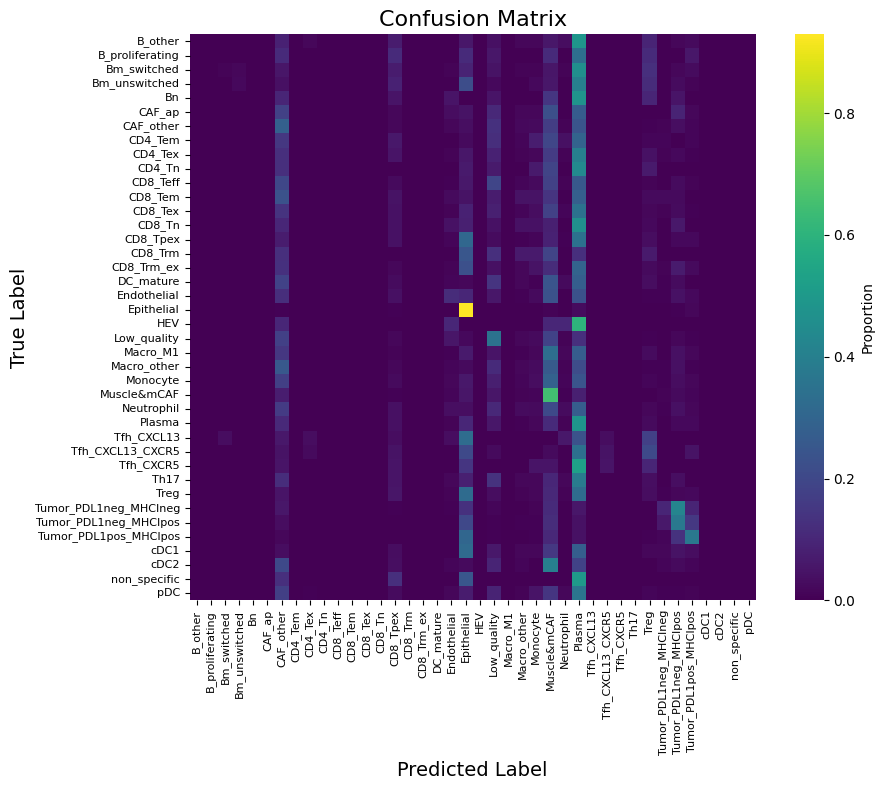

In [ ]:
# Compute and visualize confusion matrix
print("Computing confusion matrix...")

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Only keep classes that appear
unique_labels = np.unique(np.concatenate([test_labels, test_preds]))
actual_class_names = [class_names[i] for i in unique_labels]

cm = confusion_matrix(test_labels, test_preds, labels=unique_labels)

# Normalize by row for visual balance
cm_vis = cm.astype(float) / cm.sum(axis=1, keepdims=True)

plt.figure(figsize=(10, 8))

sns.heatmap(
    cm_vis,
    cmap="viridis",
    xticklabels=actual_class_names,
    yticklabels=actual_class_names,
    square=True,
    cbar_kws={"label": "Proportion"}
)

plt.title("Confusion Matrix", fontsize=16)
plt.xlabel("Predicted Label", fontsize=14)
plt.ylabel("True Label", fontsize=14)

plt.xticks(rotation=90, fontsize=8)
plt.yticks(rotation=0, fontsize=8)

plt.tight_layout()
# plt.savefig("confusion_matrix_main.pdf", dpi=600, bbox_inches="tight")
plt.show()

Visualizing per-class performance...


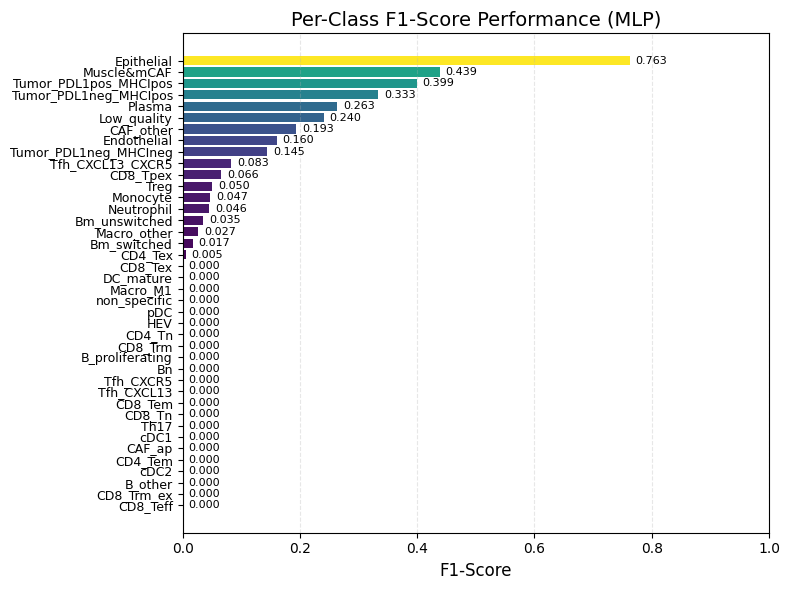


Model Summary:
  Device: cuda
  Training samples: 57959
  Test samples: 24840
  Total classes (before filtering): 42
  Actual classes in test set: 40
  Feature dimension: 384
  Model parameters: 340,778
  Best epoch: 13
  Test Accuracy: 0.3524
  Test Macro F1: 0.0828
  Test Weighted F1: 0.2837


In [24]:
# Visualize per-class F1 scores
print("Visualizing per-class performance...")

fig, ax = plt.subplots(figsize=(8, 6))
metrics_df_sorted = metrics_df.sort_values('F1-Score', ascending=True)

x_pos = np.arange(len(metrics_df_sorted))
colors = plt.cm.viridis(metrics_df_sorted['F1-Score'] / metrics_df_sorted['F1-Score'].max())

bars = ax.barh(x_pos, metrics_df_sorted['F1-Score'], color=colors)
ax.set_yticks(x_pos)
ax.set_yticklabels(metrics_df_sorted.index, fontsize=9)
ax.set_xlabel('F1-Score', fontsize=12)
ax.set_title('Per-Class F1-Score Performance (MLP)', fontsize=14)
ax.set_xlim([0, 1.0])
ax.grid(axis='x', alpha=0.3, linestyle='--')

# Add value labels on bars
for i, (idx, row) in enumerate(metrics_df_sorted.iterrows()):
    ax.text(row['F1-Score'] + 0.01, i, f"{row['F1-Score']:.3f}", 
            va='center', fontsize=8)

plt.tight_layout()
plt.show()

# Summary
print(f"\nModel Summary:")
print(f"  Device: {device}")
print(f"  Training samples: {len(train_dataset)}")
print(f"  Test samples: {len(val_dataset)}")
print(f"  Total classes (before filtering): {len(class_names)}")
print(f"  Actual classes in test set: {len(unique_labels)}")
print(f"  Feature dimension: {input_dim}")
print(f"  Model parameters: {sum(p.numel() for p in model.parameters()):,}")
print(f"  Best epoch: {best_epoch}")
print(f"  Test Accuracy: {test_acc:.4f}")
print(f"  Test Macro F1: {test_macro_f1:.4f}")
print(f"  Test Weighted F1: {test_weighted_f1:.4f}")

In [ ]:
# Hyperparameter tuning with 5-fold cross-validation
print("Hyperparameter tuning with 5-fold cross-validation...")

# Define parameter grid for MLP
# hidden_layer_sizes: tuple of layer sizes, e.g., (100,) means one hidden layer with 100 neurons
# activation: activation function ('relu', 'tanh', 'logistic')
# alpha: L2 regularization parameter (smaller = stronger regularization)
# learning_rate: learning rate schedule ('constant', 'invscaling', 'adaptive')
# learning_rate_init: initial learning rate

param_grid = {
    'hidden_layer_sizes': [(128,), (256,), (512,), (128, 64), (256, 128)],
    'activation': ['relu', 'tanh'],
    'alpha': [0.0001, 0.001, 0.01],
    'learning_rate': ['adaptive'],
    'learning_rate_init': [0.001, 0.01],
    'max_iter': [500],
    'early_stopping': [True],
    'validation_fraction': [0.1]
}

# Use stratified K-fold for cross-validation
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Create base model
base_model = MLPClassifier(random_state=42, verbose=False)

# Grid search with cross-validation
print("  Running grid search (this may take a while)...")
print(f"  Total combinations: {len(param_grid['hidden_layer_sizes']) * len(param_grid['activation']) * len(param_grid['alpha']) * len(param_grid['learning_rate_init'])}")
grid_search = GridSearchCV(
    base_model, 
    param_grid, 
    cv=cv, 
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train_scaled, y_train_encoded)

print(f"\n  Best parameters found:")
for param, value in grid_search.best_params_.items():
    print(f"    {param}: {value}")
print(f"  Best CV score: {grid_search.best_score_:.4f}")

# Get best model
best_model = grid_search.best_estimator_

Hyperparameter tuning with 5-fold cross-validation...
  Running grid search (this may take a while)...
Fitting 5 folds for each of 25 candidates, totalling 125 fits


In [ ]:
import torch
print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0))



## MLP
import torch
import torch.nn as nn

class MLPClassifier(nn.Module):
    def __init__(self, input_dim=384, num_classes=42):
        super().__init__()
        
        self.net = nn.Sequential(
            nn.Linear(input_dim, 512),
            nn.GELU(),
            nn.BatchNorm1d(512),
            nn.Dropout(0.3),

            nn.Linear(512, 256),
            nn.GELU(),
            nn.BatchNorm1d(256),
            nn.Dropout(0.3),

            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        return self.net(x)


## DataLoader
from torch.utils.data import DataLoader

train_loader = DataLoader(
    train_dataset,
    batch_size=1024,      # GPU 可以大一点
    shuffle=True,
    num_workers=4,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=2048,
    shuffle=False,
    num_workers=4,
    pin_memory=True
)


## setting
device = torch.device("cuda")

model = MLPClassifier().to(device)

criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=5e-4,
    weight_decay=1e-4
)

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=30
)

scaler = torch.cuda.amp.GradScaler()  # AMP


## Cycle
from sklearn.metrics import f1_score
import numpy as np

def evaluate(model, loader):
    model.eval()
    all_preds, all_labels = [], []

    with torch.no_grad():
        for x, y in loader:
            x = x.to(device, non_blocking=True)
            y = y.to(device, non_blocking=True)

            with torch.cuda.amp.autocast():
                logits = model(x)

            preds = torch.argmax(logits, dim=1)

            all_preds.append(preds.cpu().numpy())
            all_labels.append(y.cpu().numpy())

    all_preds = np.concatenate(all_preds)
    all_labels = np.concatenate(all_labels)

    acc = (all_preds == all_labels).mean()
    macro_f1 = f1_score(all_labels, all_preds, average="macro")

    return acc, macro_f1


best_f1 = 0
patience = 5
counter = 0

for epoch in range(30):
    model.train()
    total_loss = 0

    for x, y in train_loader:
        x = x.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True)

        optimizer.zero_grad()

        with torch.cuda.amp.autocast():
            logits = model(x)
            loss = criterion(logits, y)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        total_loss += loss.item()

    scheduler.step()

    val_acc, val_f1 = evaluate(model, val_loader)

    print(f"\nEpoch {epoch+1}")
    print(f"Train Loss: {total_loss:.4f}")
    print(f"Val Acc: {val_acc:.4f}")
    print(f"Val Macro-F1: {val_f1:.4f}")

    if val_f1 > best_f1:
        best_f1 = val_f1
        torch.save(model.state_dict(), "best_mlp_gpu.pt")
        counter = 0
    else:
        counter += 1
        if counter >= patience:
            print("Early stopping triggered.")
            break



In [ ]:
# Evaluate on test set
print("Evaluating model on test set...")

# Predictions
y_pred = best_model.predict(X_test_scaled)
y_pred_proba = best_model.predict_proba(X_test_scaled)

# Calculate metrics
accuracy = accuracy_score(y_test_encoded, y_pred)
precision_macro = precision_score(y_test_encoded, y_pred, average='macro', zero_division=0)
recall_macro = recall_score(y_test_encoded, y_pred, average='macro', zero_division=0)
f1_macro = f1_score(y_test_encoded, y_pred, average='macro', zero_division=0)

precision_weighted = precision_score(y_test_encoded, y_pred, average='weighted', zero_division=0)
recall_weighted = recall_score(y_test_encoded, y_pred, average='weighted', zero_division=0)
f1_weighted = f1_score(y_test_encoded, y_pred, average='weighted', zero_division=0)

print(f"\nTest Set Performance:")
print(f"  Accuracy: {accuracy:.4f}")
print(f"\n  Macro-averaged metrics:")
print(f"    Precision: {precision_macro:.4f}")
print(f"    Recall: {recall_macro:.4f}")
print(f"    F1-score: {f1_macro:.4f}")
print(f"\n  Weighted-averaged metrics:")
print(f"    Precision: {precision_weighted:.4f}")
print(f"    Recall: {recall_weighted:.4f}")
print(f"    F1-score: {f1_weighted:.4f}")

# Detailed classification report
print(f"\nDetailed Classification Report:")
print(classification_report(y_test_encoded, y_pred, target_names=class_names, zero_division=0))

In [ ]:
# Compute and visualize confusion matrix
print("Computing confusion matrix...")

cm = confusion_matrix(y_test_encoded, y_pred)

# Normalize confusion matrix (percentages)
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100

# Create figure with two subplots
fig, axes = plt.subplots(1, 2, figsize=(24, 10))

# Plot 1: Raw counts
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=class_names, yticklabels=class_names,
            ax=axes[0], cbar_kws={'label': 'Count'})
axes[0].set_title('Confusion Matrix (Raw Counts)', fontsize=14)
axes[0].set_xlabel('Predicted Cell Type', fontsize=12)
axes[0].set_ylabel('True Cell Type', fontsize=12)
axes[0].tick_params(axis='x', rotation=90, labelsize=8)
axes[0].tick_params(axis='y', rotation=0, labelsize=8)

# Plot 2: Normalized (percentages)
sns.heatmap(cm_normalized, annot=True, fmt='.1f', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names,
            ax=axes[1], cbar_kws={'label': 'Percentage (%)'})
axes[1].set_title('Confusion Matrix (Normalized, %)', fontsize=14)
axes[1].set_xlabel('Predicted Cell Type', fontsize=12)
axes[1].set_ylabel('True Cell Type', fontsize=12)
axes[1].tick_params(axis='x', rotation=90, labelsize=8)
axes[1].tick_params(axis='y', rotation=0, labelsize=8)

plt.tight_layout()
plt.show()

# Print per-class metrics
print("\nPer-class Performance Metrics:")
per_class_metrics = precision_recall_fscore_support(
    y_test_encoded, y_pred, labels=range(len(class_names)), zero_division=0
)
metrics_df = pd.DataFrame({
    'Precision': per_class_metrics[0],
    'Recall': per_class_metrics[1],
    'F1-Score': per_class_metrics[2],
    'Support': per_class_metrics[3]
}, index=class_names)
metrics_df = metrics_df.sort_values('Support', ascending=False)
print(metrics_df)

In [ ]:
# Additional visualizations: Per-class F1 scores
print("Visualizing per-class performance...")

fig, ax = plt.subplots(figsize=(14, 8))
metrics_df_sorted = metrics_df.sort_values('F1-Score', ascending=True)

x_pos = np.arange(len(metrics_df_sorted))
colors = plt.cm.viridis(metrics_df_sorted['F1-Score'] / metrics_df_sorted['F1-Score'].max())

bars = ax.barh(x_pos, metrics_df_sorted['F1-Score'], color=colors)
ax.set_yticks(x_pos)
ax.set_yticklabels(metrics_df_sorted.index, fontsize=9)
ax.set_xlabel('F1-Score', fontsize=12)
ax.set_title('Per-Class F1-Score Performance', fontsize=14)
ax.set_xlim([0, 1.0])
ax.grid(axis='x', alpha=0.3, linestyle='--')

# Add value labels on bars
for i, (idx, row) in enumerate(metrics_df_sorted.iterrows()):
    ax.text(row['F1-Score'] + 0.01, i, f"{row['F1-Score']:.3f}", 
            va='center', fontsize=8)

plt.tight_layout()
plt.show()

# Summary statistics
print(f"\nModel Summary:")
print(f"  Total samples: {len(matched_data)}")
print(f"  Training samples: {len(X_train)}")
print(f"  Test samples: {len(X_test)}")
print(f"  Number of classes: {len(class_names)}")
print(f"  Feature dimension: {X_train.shape[1]}")
print(f"  Best hidden_layer_sizes: {grid_search.best_params_['hidden_layer_sizes']}")
print(f"  Best activation: {grid_search.best_params_['activation']}")
print(f"  Best alpha (regularization): {grid_search.best_params_['alpha']}")
print(f"  Best learning_rate_init: {grid_search.best_params_['learning_rate_init']}")
print(f"  Best CV accuracy: {grid_search.best_score_:.4f}")
print(f"  Test accuracy: {accuracy:.4f}")

logger.info(
    f'tissue_position range: '
    f'{tissue_position["pxl_row_in_fullres"].max()}'
    f'{tissue_position["pxl_col_in_fullres"].max()}'
)

[2026-02-26 13:21:39] INFO - tissue_position range: 14927.859760810934 9597.832102767605

Detailed information for each ROI:
ROI  1 [tumor1]:  82805 cells, X=[620.8, 4659.1], Y=[1.1, 3773.2]


## Others

In [ ]:
# Apply ROI division (based on Parent column)
roi_dict = divide_into_rois_by_parent(ncrt_anno_df1)

print(f"ROI division completed, total {len(roi_dict)} ROIs")
print(f"\nDetailed information for each ROI:")
for roi_id in sorted(roi_dict.keys()):
    roi_info = roi_dict[roi_id]
    n_cells = len(roi_info['data'])
    print(f"ROI {roi_id:2d} [{roi_info['parent']}]: {n_cells:6d} cells, "
          f"X=[{roi_info['x_min']:.1f}, {roi_info['x_max']:.1f}], "
          f"Y=[{roi_info['y_min']:.1f}, {roi_info['y_max']:.1f}]")

ROI division completed, total 14 ROIs

Detailed information for each ROI:
ROI  1 [tumor1]:  82805 cells, X=[620.8, 4659.1], Y=[1.1, 3773.2]
ROI  2 [tumor2]:  67990 cells, X=[4863.2, 9050.5], Y=[2.1, 3841.5]
ROI  3 [tumor3]:  77130 cells, X=[9319.2, 13369.2], Y=[1.2, 3824.1]
ROI  4 [tumor4]:  46044 cells, X=[13791.5, 17930.1], Y=[2.8, 3799.7]
ROI  5 [tumor5]:  72694 cells, X=[491.4, 4684.4], Y=[4518.3, 8557.5]
ROI  6 [tumor6]:  58247 cells, X=[5176.5, 8993.7], Y=[4553.1, 8703.9]
ROI  7 [tumor7]:  23008 cells, X=[9272.7, 13427.9], Y=[4625.5, 8715.1]
ROI  8 [tumor8]:  46964 cells, X=[13749.2, 17978.8], Y=[4686.2, 8756.7]
ROI  9 [tumor9]:  65065 cells, X=[587.0, 4577.4], Y=[9224.4, 13500.4]
ROI 10 [tumor10]:  58370 cells, X=[4881.8, 9012.4], Y=[9329.2, 13488.5]
ROI 11 [tumor11]:  70336 cells, X=[9273.6, 13482.2], Y=[9504.9, 13613.3]
ROI 12 [tumor12]:  72453 cells, X=[13851.7, 17466.6], Y=[9528.1, 13683.7]
ROI 13 [tumor13]:  64680 cells, X=[544.8, 4761.8], Y=[14048.1, 18196.3]
ROI 14 [tumor

In [ ]:
print('Columns:', ncrt_anno_df1.columns.tolist()); 
print('ROI unique values:', sorted(ncrt_anno_df1['ROI'].unique()) if 'ROI' in ncrt_anno_df1.columns else 'No ROI column'); 
print('Image unique values:', ncrt_anno_df1['Image'].unique()[:20] if 'Image' in ncrt_anno_df1.columns else 'No Image column'); 
print('Shape:', ncrt_anno_df1.shape); 
print('Sample:'); 
print(ncrt_anno_df1[['Image', 'ROI', 'Centroid X µm', 'Centroid Y µm']])

Columns: ['Image', 'Object ID', 'Name', 'Class', 'Parent', 'ROI', 'Centroid X µm', 'Centroid Y µm', 'Detection probability', 'Nucleus: Area µm^2', 'Cell: Area µm^2', 'Nucleus/Cell area ratio', 'DAPI: Nucleus: Mean', 'CLEC9A: Cell: Mean', 'CD31: Cell: Mean', 'CD4: Cell: Mean', 'CD23: Cell: Mean', 'DC-LAMP: Cell: Mean', 'CD86: Cell: Mean', 'CXCL13: Cell: Mean', 'CD20: Cell: Mean', 'CD68: Cell: Mean', 'CD45RO: Cell: Mean', 'CD11b: Cell: Mean', 'CD11c: Cell: Mean', 'TIM3: Cell: Mean', 'SMA: Cell: Mean', 'CD1c: Cell: Mean', 'CCL19: Cell: Mean', 'CD103: Cell: Mean', 'CXCR4: Cell: Mean', 'CXCR5: Cell: Mean', 'Pan-Cytokeratin: Cell: Mean', 'FOXP3: Nucleus: Mean', 'CD8: Cell: Mean', 'Vimentin: Cell: Mean', 'HLA-DR: Cell: Mean', 'HLA-A: Cell: Mean', 'CD15: Cell: Mean', 'TIGIT: Cell: Mean', 'CD21: Cell: Mean', 'PDPN: Cell: Mean', 'PNAd: Cell: Mean', 'IgD: Cell: Mean', 'Ki67: Nucleus: Mean', 'RORc: Nucleus: Mean', 'CCR7: Cell: Mean', 'CD45RA: Cell: Mean', 'PD-1: Cell: Mean', 'CD14: Cell: Mean', 'C

In [ ]:
## 检查 HE 图像与 CODEX 数据的坐标对应关系。
## CODEX 数据来自 PCF 图像（35520 x 66240），而 HE 图像尺寸不同（47040 x 70560）

## Get pixel size from HE image
he_path = f'{path}Hist2Pheno/data/CODEX/ESCC/{therapy_data}/NCRT HE.qptiff'
print("HE path:", he_path)
print("Exists:", os.path.exists(he_path))

width_HE = height_HE = None

if HAS_OPENSLIDE:
    # 用 openslide 读取 WSI 尺寸
    slide = openslide.OpenSlide(he_path)
    width_HE, height_HE = slide.dimensions  # (width, height)
    slide.close()
    print(f"Using OpenSlide -> width: {width_HE}, height: {height_HE}")
elif HAS_TIFFFILE:
    import tifffile as tiff
    with tiff.TiffFile(he_path) as tif:
        page = tif.pages[0]
        # page.shape 通常是 (height, width, channel)
        h, w = page.shape[:2]
        width_HE, height_HE = w, h
    print(f"Using tifffile -> width: {width}, height: {height}")
else:
    print("Neither OpenSlide nor tifffile is available.")


## Get pixel size from PCF image
segment_path = f'{path}Hist2Pheno/data/CODEX/ESCC/{therapy_data}/{segment_data}'
pixel_size_um, width_PCF, height_PCF = get_pixel_size_from_server_json(segment_path)
pixel_size = pixel_size_um

############################################
# Check the full coordinate ranges 
############################################
## for all ROIs
# print("\nCombined (seg 1-14 + 15-28):")
# df_all = pd.concat([ncrt_anno_df1, ncrt_anno_df2])

## for seg 1-14
print("\n(seg 1-14):")
df_all = ncrt_anno_df1

############################################
print("Full CODEX data coordinate ranges:")
print(f"X: {df_all['Centroid X µm'].min():.2f} - {df_all['Centroid X µm'].max():.2f} µm")
print(f"Y: {df_all['Centroid Y µm'].min():.2f} - {df_all['Centroid Y µm'].max():.2f} µm")

print(f"\nIn pixels (pixel_size={pixel_size}):")
x_min_px = df_all['Centroid X µm'].min() / pixel_size
x_max_px = df_all['Centroid X µm'].max() / pixel_size
y_min_px = df_all['Centroid Y µm'].min() / pixel_size
y_max_px = df_all['Centroid Y µm'].max() / pixel_size

print(f"X: {x_min_px:.0f} - {x_max_px:.0f} pixels")
print(f"Y: {y_min_px:.0f} - {y_max_px:.0f} pixels")

# print(f"\nCODEX image size (from server.json): 35520 x 66240 pixels")
# print(f"HE image size: 47040 x 70560 pixels")
print(f"\nCODEX image size (from server.json): {width_PCF} x {height_PCF} pixels")
print(f"HE image size: {width_HE} x {height_HE} pixels")

# Calculate potential offsets
x_offset = (width_HE - width_PCF) / 2   
y_offset = (height_HE - height_PCF) / 2

print(f"\nPotential offsets (if HE image is larger with padding):")
print(f"X offset: {x_offset:.0f} pixels")
print(f"Y offset: {y_offset:.0f} pixels")

# Check if HE image might have the CODEX region at a specific location
print(f"\nIf HE image contains CODEX region with offset:")
print(f"HE X range for CODEX: {x_offset:.0f} - {x_offset + width_PCF:.0f}")
print(f"HE Y range for CODEX: {y_offset:.0f} - {y_offset + height_PCF:.0f}")

HE path: /home/lingyu/data/Python/Collaborate/esccAI/data/NCRT/NCRT HE.qptiff
Exists: True
Using OpenSlide -> width: 47040, height: 70560
pixel_size_um read from server.json: 0.508248 µm
width read from server.json: 35520
height read from server.json: 66240

(seg 1-14):
Full CODEX data coordinate ranges:
X: 491.43 - 17978.80 µm
Y: 1.15 - 18341.50 µm

In pixels (pixel_size=0.5082483404568044):
X: 967 - 35374 pixels
Y: 2 - 36088 pixels

CODEX image size (from server.json): 35520 x 66240 pixels
HE image size: 47040 x 70560 pixels

Potential offsets (if HE image is larger with padding):
X offset: 5760 pixels
Y offset: 2160 pixels

If HE image contains CODEX region with offset:
HE X range for CODEX: 5760 - 41280
HE Y range for CODEX: 2160 - 68400


In [ ]:
# Get pixel size
segment_path = f'{path}Hist2Pheno/data/CODEX/ESCC/{therapy_data}/{segment_data}'
pixel_size_um, width_PCF, height_PCF = get_pixel_size_from_server_json(segment_path)

# Test reading HE image
he_image_path = f'{path}Hist2Pheno/data/CODEX/ESCC/{therapy_data}/NCRT HE.qptiff'
print(f"\nHE image path: {he_image_path}")

# Try to read image information (don't read full image, only thumbnail)
try:
    if HAS_OPENSLIDE:
        slide = openslide.OpenSlide(he_image_path)
        print(f"Image dimensions (level 0): {slide.level_dimensions[0]}")
        print(f"Number of pyramid levels: {slide.level_count}")
        # Read lowest resolution level as preview
        preview_level = slide.level_count - 1
        preview_dims = slide.level_dimensions[preview_level]
        print(f"Preview dimensions (level {preview_level}): {preview_dims}")
        slide.close()
    else:
        print("openslide needed to read image information")
except Exception as e:
    print(f"Failed to read image information: {e}")

pixel_size_um read from server.json: 0.508248 µm
width read from server.json: 35520
height read from server.json: 66240

HE image path: /home/lingyu/data/Python/Collaborate/esccAI/data/NCRT/NCRT HE.qptiff
Image dimensions (level 0): (47040, 70560)
Number of pyramid levels: 6
Preview dimensions (level 5): (1470, 2205)


Visualizing ROI 1


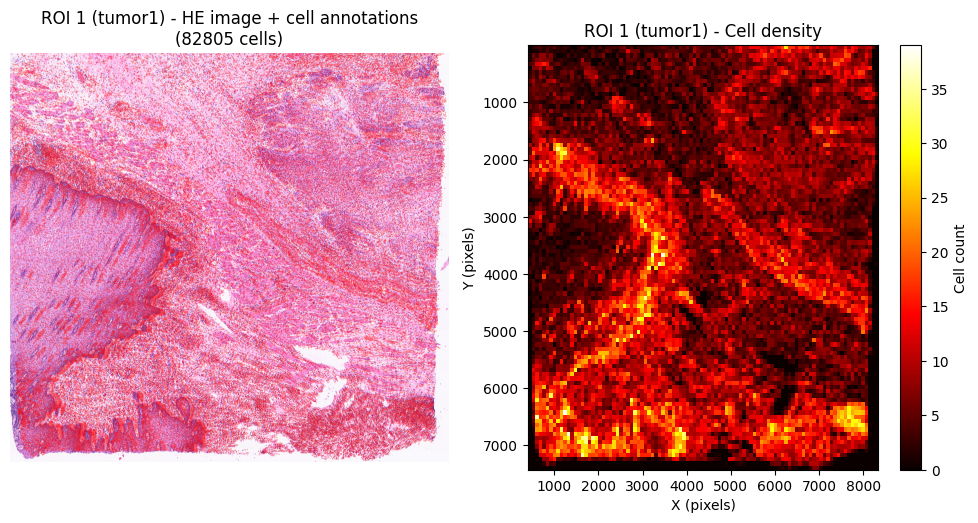

In [ ]:
# Test visualization of ROI
print("Visualizing ROI 1")
fig = visualize_roi_cells(1, roi_dict, he_image_path=he_image_path, 
                          pixel_size_um=pixel_size_um, 
                          width_PCF=width_PCF, height_PCF=height_PCF, width_HE=width_HE, height_HE=height_HE,
                          figsize=(10, 5.2))
plt.show()